In [2]:
import numpy as np
import matplotlib.pyplot as plt
import heapq, math


from __future__ import annotations
import cv2
import numpy as np
from dataclasses import dataclass
from typing import Tuple, Dict, Any, Optional, List

## 1. Warping and cropping Image

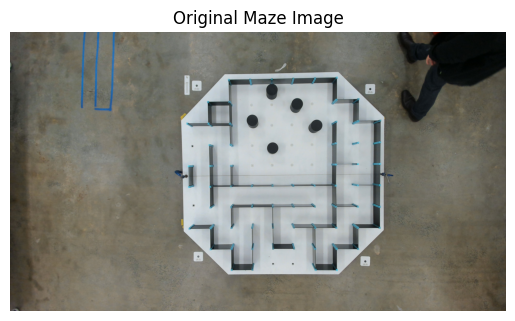

In [3]:
image_path = 'image.jpg'
image = cv2.imread(image_path)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original Maze Image')
plt.axis('off')
plt.show()

In [234]:
# # save image
# cv2.imwrite("maze_obs_img.jpg", image)

## Cropper

In [4]:
# step1_warp_board.py
# Step 1: Normalize the top camera view -> square, axis-aligned board image.
# Uses two strategies: (A) board contour; (B) 4 white corner tags. Falls back automatically.

image = cv2.imread(image_path)

# -------------------------- small helpers --------------------------

def order_corners(pts: np.ndarray) -> np.ndarray:
    """
    Order 4 points as [TL, TR, BR, BL] for a consistent homography.
    pts: (4,2) float32
    """
    pts = pts.astype(np.float32)
    s = pts.sum(axis=1)
    d = np.diff(pts, axis=1).ravel()
    tl = pts[np.argmin(s)]
    br = pts[np.argmax(s)]
    tr = pts[np.argmin(d)]
    bl = pts[np.argmax(d)]
    return np.array([tl, tr, br, bl], dtype=np.float32)

def rotate_bound(img: np.ndarray, angle_deg: float) -> np.ndarray:
    h, w = img.shape[:2]
    cX, cY = w / 2.0, h / 2.0
    M = cv2.getRotationMatrix2D((cX, cY), angle_deg, 1.0)
    cos = abs(M[0, 0]); sin = abs(M[0, 1])
    # compute new bounding dimensions
    nW = int((h * sin) + (w * cos))
    nH = int((h * cos) + (w * sin))
    # adjust the rotation matrix to take into account translation
    M[0, 2] += (nW / 2) - cX
    M[1, 2] += (nH / 2) - cY
    return cv2.warpAffine(img, M, (nW, nH), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE)

def dominant_right_angle(img: np.ndarray) -> float:
    """
    Return rotation (degrees) to align the maze to the nearest multiple of 90°.
    Positive means rotate counter-clockwise.
    """
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (3, 3), 0)
    edges = cv2.Canny(gray, 60, 160)
    lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=120, minLineLength=img.shape[1] // 12, maxLineGap=12)
    if lines is None or len(lines) == 0:
        return 0.0
    angs: List[float] = []
    for l in lines:
        x1, y1, x2, y2 = l[0]
        ang = np.degrees(np.arctan2(y2 - y1, x2 - x1))
        # map to [-90, 90)
        ang = ((ang + 90) % 180) - 90
        angs.append(ang)
    if not angs:
        return 0.0
    med = float(np.median(angs))
    nearest90 = round(med / 90.0) * 90.0
    delta = nearest90 - med
    # snap tiny jitter to exactly 0
    if abs(delta) < 0.5:
        delta = 0.0
    return delta

def warp_from_quad(img: np.ndarray, quad: np.ndarray, out_size: int = 1000) -> np.ndarray:
    quad = order_corners(quad.astype(np.float32))
    dst = np.array([[0, 0], [out_size - 1, 0], [out_size - 1, out_size - 1], [0, out_size - 1]], dtype=np.float32)
    H = cv2.getPerspectiveTransform(quad, dst)
    return cv2.warpPerspective(img, H, (out_size, out_size), flags=cv2.INTER_LINEAR)

# -------------------------- Method A: board contour --------------------------

def try_warp_by_board_contour(img: np.ndarray, out_size: int, dbg: Dict[str, Any]) -> Optional[np.ndarray]:
    """
    Detect the bright board as the largest contour and warp its minAreaRect to a square.
    Returns warped image or None if failed.
    """
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    L = lab[:, :, 0]
    # Board is bright: threshold high L; use Otsu on inverted to be robust to lighting
    _, th = cv2.threshold(L, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    # Clean up
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    th = cv2.morphologyEx(th, cv2.MORPH_CLOSE, kernel, iterations=2)

    cnts, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return None
    cnt = max(cnts, key=cv2.contourArea)
    area = cv2.contourArea(cnt)
    if area < 0.1 * img.shape[0] * img.shape[1]:  # sanity check
        return None

    rect = cv2.minAreaRect(cnt)             # ((cx,cy),(w,h),angle)
    box = cv2.boxPoints(rect)               # 4 corners
    dbg["contour_box"] = box.copy()
    warped = warp_from_quad(img, box, out_size)
    return warped

# -------------------------- Method B: corner tags --------------------------

def try_warp_by_corner_tags(img: np.ndarray, out_size: int, dbg: Dict[str, Any]) -> Optional[np.ndarray]:
    """
    Find 4 small white square tags around the board and warp using their centers.
    Returns warped image or None if failed.
    """
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    # white: low saturation, high value
    mask_white = cv2.inRange(hsv, (0, 0, 180), (180, 70, 255))
    # remove tiny and merge pieces
    mask_white = cv2.morphologyEx(mask_white, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8), iterations=1)
    mask_white = cv2.morphologyEx(mask_white, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8), iterations=2)

    cnts, _ = cv2.findContours(mask_white, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return None

    h, w = img.shape[:2]
    cen = np.array([w / 2.0, h / 2.0])
    cands = []
    for c in cnts:
        area = cv2.contourArea(c)
        if area < 150 or area > 8000:
            continue
        x, y, bw, bh = cv2.boundingRect(c)
        ar = bw / float(bh)
        if ar < 0.6 or ar > 1.6:
            continue
        # must be fairly compact (squares with text)
        peri = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.05 * peri, True)
        if len(approx) < 4:  # allow slightly rounded
            continue
        M = cv2.moments(c)
        if M["m00"] == 0:
            continue
        cx = M["m10"] / M["m00"]
        cy = M["m01"] / M["m00"]
        dist = np.linalg.norm(np.array([cx, cy]) - cen)
        cands.append((dist, np.array([cx, cy], dtype=np.float32)))
    # pick the 4 farthest from center (they sit near the corners)
    if len(cands) < 4:
        return None
    cands.sort(key=lambda t: t[0], reverse=True)
    pts = np.array([p for _, p in cands[:4]], dtype=np.float32)
    dbg["tag_points_image"] = pts.copy()

    # Order by corners (TL, TR, BR, BL)
    quad = order_corners(pts)
    warped = warp_from_quad(img, quad, out_size)
    return warped

# -------------------------- Final wrapper --------------------------

@dataclass
class WarpResult:
    warped: np.ndarray
    method: str
    debug: Dict[str, Any]

def warp_maze_board(
    img_bgr: np.ndarray,
    out_size: int = 1000,
    prefer: str = "auto",  # "auto" | "contour" | "tags"
    rotate_to_axis: bool = True,
) -> WarpResult:
    """
    Try method A then B (or vice-versa if prefer="tags").
    Returns a square, axis-aligned board image and diagnostics.
    """
    dbg: Dict[str, Any] = {}

    methods = ["contour", "tags"] if prefer in ("auto", "contour") else ["tags", "contour"]

    warped = None
    used = None
    for m in methods:
        if m == "contour":
            warped = try_warp_by_board_contour(img_bgr, out_size, dbg)
        else:
            warped = try_warp_by_corner_tags(img_bgr, out_size, dbg)
        if warped is not None:
            used = m
            break

    if warped is None:
        raise RuntimeError("Step 1 failed: could not compute a reliable homography using either method.")

    if rotate_to_axis:
        delta = dominant_right_angle(warped)
        dbg["rotation_delta_deg"] = delta
        if abs(delta) > 0.01:
            warped = rotate_bound(warped, delta)
            # After rotation, center-crop back to out_size×out_size (pad/crop)
            h, w = warped.shape[:2]
            y0 = max(0, (h - out_size) // 2)
            x0 = max(0, (w - out_size) // 2)
            warped = warped[y0:y0 + out_size, x0:x0 + out_size].copy()
            if warped.shape[0] != out_size or warped.shape[1] != out_size:
                warped = cv2.resize(warped, (out_size, out_size), interpolation=cv2.INTER_LINEAR)

    return WarpResult(warped=warped, method=used or "unknown", debug=dbg)


    # ap.add_argument("--size", type=int, default=1000, help="Output square size (pixels)")
    # ap.add_argument("--prefer", choices=["auto", "contour", "tags"], default="auto", help="Prefer a method; still falls back")
    # ap.add_argument("--no-rotate", action="store_true", help="Disable auto axis alignment")

if image is None:
    raise SystemExit(f"Could not read image")

res = warp_maze_board(image, out_size=1200, prefer="auto")
# cv2.imwrite(args.out, res.warped)

print(f"[OK] warped |  method={res.method}  rotation={res.debug.get('rotation_delta_deg', 0):.2f}°")


[OK] warped |  method=contour  rotation=0.00°


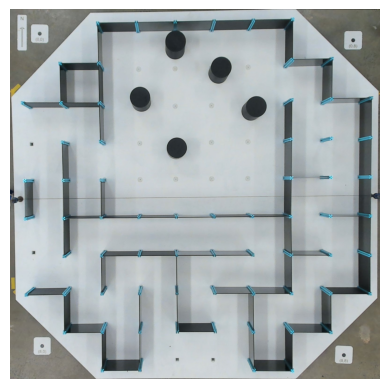

In [5]:
plt.imshow(cv2.cvtColor(res.warped, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

## 2. Normalizing image brightness

In [6]:

def _solid_board_mask(bgr):
    """Intensity-only board silhouette (no holes)."""
    lab = cv2.cvtColor(bgr, cv2.COLOR_BGR2LAB)
    L = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)).apply(lab[:,:,0])
    th = cv2.adaptiveThreshold(L, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                               cv2.THRESH_BINARY, 51, -10)
    cnts, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mask = np.zeros_like(L, np.uint8)
    if cnts:
        cv2.drawContours(mask, [max(cnts, key=cv2.contourArea)], -1, 255, -1)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((9,9),np.uint8), 1)
    return mask

def standardize_brightness_to_floor(bgr,
                                    target_L=240,         # desired floor lightness (0–255)
                                    ab_thresh=12,         # how “neutral” a/b must be to count as white
                                    erode_frac=0.015,     # stay away from walls/edges
                                    q=95,                 # use this percentile of floor pixels as reference
                                    alpha_clip=(0.6,1.8), # clamp scale to avoid extremes
                                    return_alpha=False):
    """
    Scale only the Lab L* channel so that the white floor reaches target_L.
    Works with variable lighting; no HSV used.
    """
    H, W = bgr.shape[:2]
    board = _solid_board_mask(bgr)

    # avoid edges so we sample clear floor
    k = max(1, int(erode_frac * min(H, W))) | 1
    board_eroded = cv2.erode(board, np.ones((k, k), np.uint8), 1)

    lab = cv2.cvtColor(bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
    L, a, b = lab[:,:,0], lab[:,:,1], lab[:,:,2]

    # "white" = near-neutral a/b (OpenCV Lab has 128 as neutral)
    white = (np.abs(a-128) <= ab_thresh) & (np.abs(b-128) <= ab_thresh) & (board_eroded > 0)

    # robust reference lightness
    floor_vals = L[white]
    if floor_vals.size < 500:            # fallback: use bright part of board if white sample is tiny
        floor_vals = L[board_eroded > 0]
    ref = float(np.percentile(floor_vals, q))

    # scale factor to hit target_L
    alpha = np.clip(target_L / max(1.0, ref), alpha_clip[0], alpha_clip[1])

    Ln = np.clip(L * alpha, 0, 255)
    lab[:,:,0] = Ln
    out = cv2.cvtColor(lab.astype(np.uint8), cv2.COLOR_LAB2BGR)
    return (out, float(alpha)) if return_alpha else out


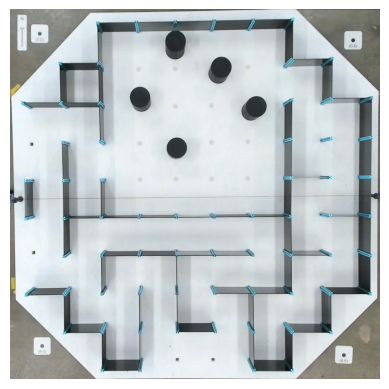

In [7]:

# Or normalize the warped board directly (works too)
warped_norm = standardize_brightness_to_floor(res.warped)


plt.imshow(cv2.cvtColor(warped_norm, cv2.COLOR_BGR2RGB))
# plt.title('Warped Maze Image')
plt.axis('off')
plt.show()


## 3. Wall Detection

In [8]:
# Step 2 tunables (adjust only if needed)
N_CELLS = 9

# relative darkness vs board median (in Lab L* after CLAHE)
DELTA_L = 60                 # bigger => more walls captured; try 16–24,,  75 /////////////////////////////////////////

# blackhat kernel for dark bars on light background, increase if no white lines found
BLACKHAT_K = 10                # odd number; try 15–21,  3 ///////////////////////////////////////

# cyan highlights (teal end-caps)
CYAN_H = (80, 105)              # OpenCV H in [0,180]
CYAN_S = (40, 255)
CYAN_V = (40, 255)

# morphology
CLOSE_ITERS = 2                 # seals hairline gaps
OPEN_ITERS  = 1                 # removes speckles
DILATE_ITERS = 1                # thickens walls slightly

# remove tiny blobs (area in px) that slip through
MIN_AREA = 120


In [9]:

def otsu_on_values(vals_uint8: np.ndarray) -> int:
    """Otsu on a 1D uint8 array; returns threshold in [0..255]."""
    hist = np.bincount(vals_uint8, minlength=256).astype(np.float64)
    prob = hist / hist.sum()
    omega = np.cumsum(prob)
    mu = np.cumsum(prob * np.arange(256))
    mu_t = mu[-1]
    sigma_b2 = (mu_t*omega - mu)**2 / (omega*(1.0 - omega) + 1e-9)
    k = np.nanargmax(sigma_b2)
    return int(k)

def remove_small_components(bin_img: np.ndarray, min_area: int) -> np.ndarray:
    """Keep only connected components with area >= min_area (8-connectivity)."""
    num, labels, stats, _ = cv2.connectedComponentsWithStats(bin_img, connectivity=8)
    keep = np.zeros_like(bin_img)
    for i in range(1, num):  # 0 is background
        if stats[i, cv2.CC_STAT_AREA] >= min_area:
            keep[labels == i] = 255
    return keep




In [10]:
def extract_wall_mask_robust(img_bgr,
                             delta_L=DELTA_L,
                             k_bh=BLACKHAT_K,
                             cyan_h=CYAN_H, cyan_s=CYAN_S, cyan_v=CYAN_V,
                             close_iters=CLOSE_ITERS, open_iters=OPEN_ITERS, dilate_iters=DILATE_ITERS,
                             min_area=MIN_AREA,
                             debug=True):
    H, W = img_bgr.shape[:2]

    # --- color spaces
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB); L = lab[:, :, 0]
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    # --- board mask (white, low S / high V region), then dilate to include walls
    board0 = cv2.inRange(hsv, (0, 0, 170), (180, 70, 255))
    board = cv2.morphologyEx(board0, cv2.MORPH_CLOSE, np.ones((7,7),np.uint8), 2)
    board = cv2.dilate(board, np.ones((9,9),np.uint8), 1)
    # keep largest component only
    num, labels, stats, _ = cv2.connectedComponentsWithStats(board, connectivity=8)
    if num > 1:
        big = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        board = np.where(labels == big, 255, 0).astype(np.uint8)

    # --- CLAHE to boost contrast on L*
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    L_eq = clahe.apply(L)

    # --- black-hat: dark bars on bright board
    k = cv2.getStructuringElement(cv2.MORPH_RECT, (k_bh, k_bh))
    blackhat = cv2.morphologyEx(L_eq, cv2.MORPH_BLACKHAT, k)

    # Otsu on board-only pixels
    vals = blackhat[board > 0].astype(np.uint8).ravel()
    t_bh = otsu_on_values(vals) if vals.size else 25
    bh_bin = ((blackhat >= t_bh) & (board > 0)).astype(np.uint8) * 255

    # --- relative dark vs board median
    medL = int(np.median(L_eq[board > 0])) if np.any(board) else int(np.median(L_eq))
    dark_rel = ((L_eq <= (medL - delta_L)) & (board > 0)).astype(np.uint8) * 255

    # --- cyan end-caps
    cyan = cv2.inRange(hsv, (cyan_h[0], cyan_s[0], cyan_v[0]), (cyan_h[1], cyan_s[1], cyan_v[1]))

    # --- combine cues and clean
    wall = cv2.bitwise_or(bh_bin, dark_rel)
    wall = cv2.bitwise_or(wall, cyan)
    wall = cv2.bitwise_and(wall, board)

    wall = cv2.morphologyEx(wall, cv2.MORPH_CLOSE, np.ones((5,5),np.uint8), iterations=close_iters)
    wall = cv2.morphologyEx(wall, cv2.MORPH_OPEN,  np.ones((3,3),np.uint8), iterations=open_iters)
    if dilate_iters:
        wall = cv2.dilate(wall, np.ones((3,3),np.uint8), iterations=dilate_iters)

    if min_area > 0:
        wall = remove_small_components(wall, min_area=min_area)

    wall = (wall > 0).astype(np.uint8) * 255

    if debug:
        fig, ax = plt.subplots(2, 3, figsize=(14, 9))
        ax[0,0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)); ax[0,0].set_title("Warped"); ax[0,0].axis("off")
        ax[0,1].imshow(L_eq, cmap="gray"); ax[0,1].set_title("L* (CLAHE)"); ax[0,1].axis("off")
        ax[0,2].imshow(blackhat, cmap="gray"); ax[0,2].set_title(f"Blackhat (k={k_bh}), thr={t_bh}"); ax[0,2].axis("off")
        ax[1,0].imshow(board, cmap="gray"); ax[1,0].set_title("Board mask"); ax[1,0].axis("off")
        ax[1,1].imshow(dark_rel, cmap="gray"); ax[1,1].set_title(f"Relative dark (ΔL={delta_L})"); ax[1,1].axis("off")
        ax[1,2].imshow(cv2.bitwise_or(wall, 0), cmap="gray"); ax[1,2].set_title("Final wall mask"); ax[1,2].axis("off")
        plt.show()

    return wall

def overlay_mask(img_bgr, mask, alpha=0.45):
    ov = img_bgr.copy()
    ov[mask > 0] = (0, 0, 255)
    return cv2.addWeighted(img_bgr, 1 - alpha, ov, alpha, 0)


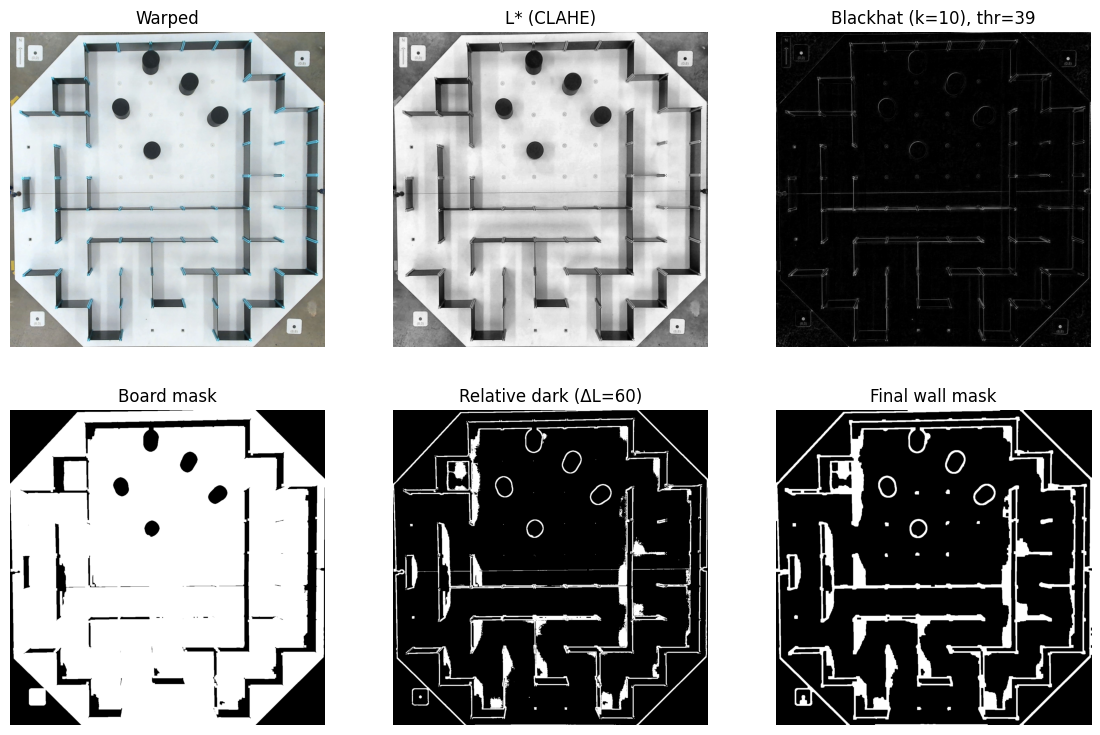

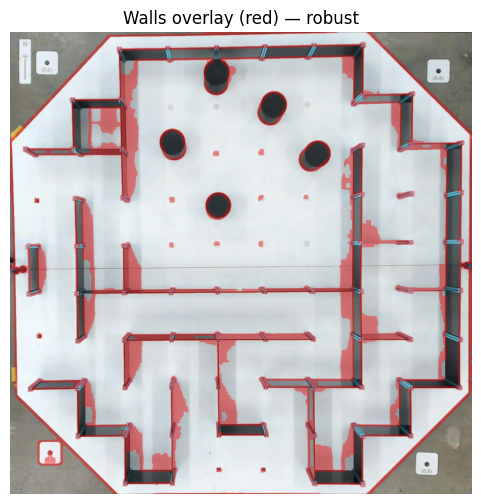

In [11]:
# warped = res.warped.copy()

wall_mask = extract_wall_mask_robust(
    warped_norm,
    delta_L=DELTA_L,
    k_bh=BLACKHAT_K,
    cyan_h=CYAN_H, cyan_s=CYAN_S, cyan_v=CYAN_V,
    close_iters=CLOSE_ITERS, open_iters=OPEN_ITERS, dilate_iters=DILATE_ITERS,
    min_area=MIN_AREA,
    debug=True
)

ov = overlay_mask(warped_norm, wall_mask, alpha=0.40)
plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(ov, cv2.COLOR_BGR2RGB))
plt.title("Walls overlay (red) — robust")
plt.axis('off')
plt.show()


## Cylinder detection

In [12]:
# --- Detect fixed-size black cylinders in a cropped image; return a binary mask ---
import numpy as np, cv2

def circle_mask_fixed_radius(
    crop_bgr,
    radius_px,                 # expected cylinder radius in pixels (e.g. from pitch*ratio)
    tol_frac=0.20,             # ± tolerance on radius (20% -> min/max radius)
    min_contrast_L=8.0,        # required L* contrast (annulus - inside) to accept
    dp=1.2,                    # Hough dp (1.1–1.5 typical)
    param1=120,                # Canny high threshold inside Hough
    param2=24,                 # Hough accumulator threshold (↑ fewer circles)
    blur_ksize=7               # Gaussian blur size (odd)
):
    """
    Returns:
        mask (H×W uint8): 255 where a cylinder is detected, else 0
        circles: list of (cx, cy, r) in pixels (relative to the cropped image)
        dbg: dict of thresholds actually used
    """
    H, W = crop_bgr.shape[:2]

    # Work in Lab L* for lighting robustness + CLAHE
    L = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2LAB)[:,:,0]
    L = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)).apply(L)
    Lb = cv2.GaussianBlur(L, (blur_ksize, blur_ksize), 1.2)

    rmin = max(1, int(round(radius_px*(1.0 - tol_frac))))
    rmax = max(rmin+1, int(round(radius_px*(1.0 + tol_frac))))
    minDist = max(10, int(round(radius_px*1.6)))  # avoid duplicate detections

    det = cv2.HoughCircles(Lb, cv2.HOUGH_GRADIENT, dp=dp, minDist=minDist,
                           param1=param1, param2=param2,
                           minRadius=rmin, maxRadius=rmax)

    mask = np.zeros((H, W), np.uint8)
    circles = []

    if det is not None:
        det = np.round(det[0]).astype(int)
        # verify each circle is a dark disk vs surrounding annulus
        for x, y, r in det:
            if x<0 or y<0 or x>=W or y>=H: 
                continue
            r_in  = max(1, int(r*0.85))
            r_o1  = max(r_in+1, int(r*1.15))
            r_o2  = max(r_o1+1, int(r*1.45))

            inner = np.zeros((H, W), np.uint8)
            ann   = np.zeros((H, W), np.uint8)
            cv2.circle(inner, (x, y), r_in, 255, -1)
            cv2.circle(ann,   (x, y), r_o2, 255, -1)
            cv2.circle(ann,   (x, y), r_o1,   0, -1)

            vi = L[inner>0]
            vo = L[ann>0]
            if vi.size < 50 or vo.size < 100:
                continue

            contrast = float(vo.mean() - vi.mean())   # bright annulus - dark center
            if contrast >= min_contrast_L:
                circles.append((int(x), int(y), int(r)))
                cv2.circle(mask, (x, y), int(r), 255, -1)

    dbg = dict(rmin=rmin, rmax=rmax, minDist=minDist, dp=dp, p1=param1, p2=param2)
    return mask, circles, dbg



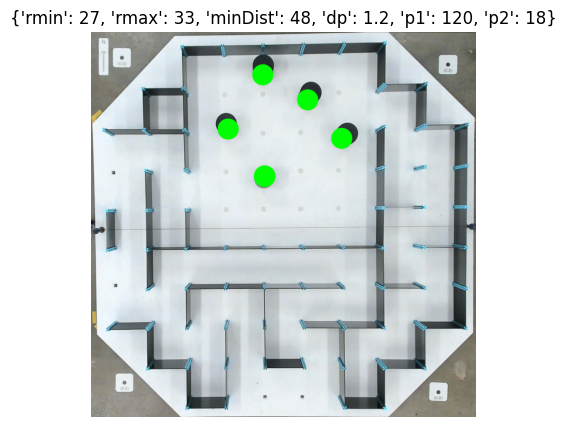

In [13]:
# ---------------- example usage ----------------
mask, circles, dbg = circle_mask_fixed_radius(warped_norm, radius_px=30, tol_frac=0.1, param2=18)

greenMask = mask

# # visualize (optional)
vis = cv2.cvtColor(warped_norm.copy(), cv2.COLOR_BGR2RGB)
vis[mask>0] = (0, 255, 0)
for (cx,cy,r) in circles:
    cv2.circle(vis, (cx,cy), r, (0,255,0), 2, cv2.LINE_AA)
plt.figure(figsize=(5,5)); plt.imshow(vis); plt.axis('off'); plt.title(dbg); plt.show()

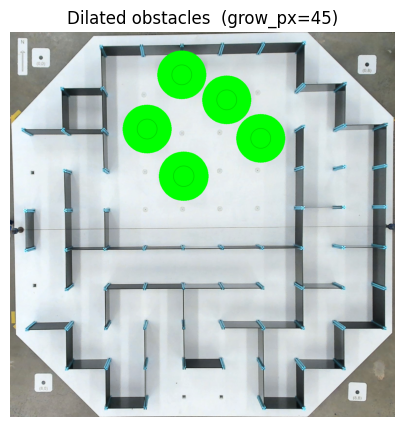

In [66]:
# --- Inflate (dilate) the cylinder mask and re-plot ---

# how much to grow: either set grow_px directly or use a fraction of the expected radius
inflate_frac = 1.5                 # grow by 12% of radius_px
grow_px = max(1, int(round(inflate_frac * 30)))

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*grow_px+1, 2*grow_px+1))
mask_dilated = cv2.dilate(mask, kernel, iterations=1)

# visualize (green on RGB preview)
vis_dil = cv2.cvtColor(warped_norm.copy(), cv2.COLOR_BGR2RGB)
vis_dil[mask_dilated > 0] = (0, 255, 0)

# (optional) show original (thin) outline for reference
for (cx, cy, r) in circles:
    cv2.circle(vis_dil, (cx, cy), r, (0, 180, 0), 1, cv2.LINE_AA)

plt.figure(figsize=(5,5))
plt.imshow(vis_dil)
plt.axis('off')
plt.title(f"Dilated obstacles  (grow_px={grow_px})")
plt.show()

# keep the inflated mask for planning
cylinder_unsafe_mask = mask_dilated


## 4. Lay down the grid

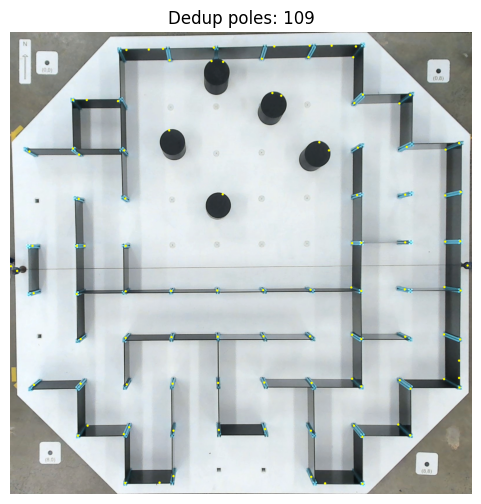

In [67]:
# ==== PARAMETERS ====
N_CELLS = 9                                # -> expect (N+1) x (N+1) grid
CYAN_H = (40, 110); CYAN_S = (47, 255); CYAN_V = (35, 255)
AREA_MIN, AREA_MAX = 10, 2000              # CC size filter for poles
OPEN_ITERS, CLOSE_ITERS = 1, 2             # morphology for pole mask
DEDUP_RADIUS_FRAC = 0.012                  # merge yellow dots closer than this * min(H,W)


def board_mask_from_warped(img_bgr):
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    m = cv2.inRange(hsv, (0,0,170), (180,70,255))
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, np.ones((7,7),np.uint8), 2)
    m = cv2.dilate(m, np.ones((9,9),np.uint8), 1)
    num, lbl, stats, _ = cv2.connectedComponentsWithStats(m, connectivity=8)
    if num > 1:
        big = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        m = (lbl == big).astype(np.uint8) * 255
    return m

def detect_cyan_poles(img_bgr):
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    lo, hi = (int(CYAN_H[0]), int(CYAN_S[0]), int(CYAN_V[0])), (int(CYAN_H[1]), int(CYAN_S[1]), int(CYAN_V[1]))
    m  = cv2.inRange(hsv, lo, hi)
    m  = cv2.bitwise_and(m, board_mask_from_warped(img_bgr))
    if OPEN_ITERS:  m = cv2.morphologyEx(m, cv2.MORPH_OPEN,  np.ones((3,3),np.uint8), OPEN_ITERS)
    if CLOSE_ITERS: m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, np.ones((5,5),np.uint8), CLOSE_ITERS)
    num, labels, stats, cents = cv2.connectedComponentsWithStats(m, connectivity=8)
    pts = []
    for i in range(1, num):
        a = stats[i, cv2.CC_STAT_AREA]
        if AREA_MIN <= a <= AREA_MAX:
            pts.append((float(cents[i,0]), float(cents[i,1])))
    return np.array(pts, np.float32), m

def dedup_points_radius(pts, radius_px):
    """Greedy radius clustering to merge near-duplicates."""
    if len(pts) == 0: return pts
    order = np.argsort(pts[:,0] + 1e-3*pts[:,1])
    r2 = radius_px*radius_px
    clusters = []
    for p in pts[order]:
        hit = None
        for c in clusters:
            dx, dy = p[0]-c[0], p[1]-c[1]
            if dx*dx + dy*dy <= r2:
                c[2] += p[0]; c[3] += p[1]; c[4] += 1
                c[0], c[1] = c[2]/c[4], c[3]/c[4]
                hit = True; break
        if not hit:
            clusters.append([p[0], p[1], p[0], p[1], 1])  # cx,cy,sumx,sumy,n
    return np.array([[c[0], c[1]] for c in clusters], np.float32)

# --- run on your warped image from Step 1
# warped = warped_norm
pts_raw, poles_mask = detect_cyan_poles(warped_norm)
H, W = warped_norm.shape[:2]
pts = dedup_points_radius(pts_raw, DEDUP_RADIUS_FRAC*min(H,W))

vis = warped_norm.copy()
for (x,y) in pts: cv2.circle(vis, (int(x),int(y)), 3, (0,255,255), -1)
plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)); plt.title(f"Dedup poles: {len(pts)}"); plt.axis('off'); plt.show()


In [68]:
# Gap-based 1-D clustering (stable, no sklearn)
def cluster_axis(vals, eps_px):
    """Group sorted 1-D values if consecutive gap <= eps_px. Returns (centers, counts)."""
    if len(vals) == 0: return [], []
    vals = np.sort(vals)
    centers, counts = [], []
    start = 0
    for i in range(1, len(vals)):
        if vals[i] - vals[i-1] > eps_px:
            seg = vals[start:i]
            centers.append(np.median(seg)); counts.append(len(seg)); start = i
    seg = vals[start:]
    centers.append(np.median(seg)); counts.append(len(seg))
    return list(centers), list(counts)

def enforce_exact_lines(centers, counts, target, min_spacing_px):
    """Merge closest until <=target, then insert midpoints of largest gaps until ==target."""
    centers = list(centers); counts = list(counts)
    # merge stage
    while len(centers) > target:
        idx = int(np.argmin(np.diff(centers)))
        # weighted average when merging
        c = (centers[idx]*counts[idx] + centers[idx+1]*counts[idx+1]) / (counts[idx]+counts[idx+1])
        centers[idx:idx+2] = [c]
        counts[idx:idx+2]  = [counts[idx]+counts[idx+1]]
    # split stage
    while len(centers) < target:
        diffs = np.diff(centers)
        j = int(np.argmax(diffs)) if diffs.size else 0
        # insert midpoint only if gap is big; otherwise extrapolate at ends
        if diffs.size and diffs[j] > min_spacing_px*0.8:
            newc = 0.5*(centers[j] + centers[j+1])
            centers.insert(j+1, newc); counts.insert(j+1, 0)
        else:
            # pad at ends to maintain monotonicity
            step = min_spacing_px
            if j == 0:
                centers.insert(0, centers[0]-step); counts.insert(0, 0)
            else:
                centers.append(centers[-1]+step); counts.append(0)
        centers = sorted(centers)
    return np.array(centers, int)

# Cluster by axis with tolerances relative to image size
EPS_X = 0.018 * W  # if two pole x's are within ~1.8% of width -> same vertical line
EPS_Y = 0.018 * H  

x_centers, x_counts = cluster_axis(pts[:,0], EPS_X)
y_centers, y_counts = cluster_axis(pts[:,1], EPS_Y)

# Enforce exactly N+1 straight, evenly-spaced lines
approx_cell_w = (max(x_centers)-min(x_centers)) / max(1, len(x_centers)-1)
approx_cell_h = (max(y_centers)-min(y_centers)) / max(1, len(y_centers)-1)
x_lines = enforce_exact_lines(x_centers, x_counts, N_CELLS+1, min_spacing_px=0.6*approx_cell_w)
y_lines = enforce_exact_lines(y_centers, y_counts, N_CELLS+1, min_spacing_px=0.6*approx_cell_h)

print(f"x-lines: {len(x_lines)}, y-lines: {len(y_lines)}")

# x_lines = [  49, 126, 199, 280, 355, 437, 515, 612, 688, 764]
# y_lines = [ 31, 116, 197, 280, 364, 437, 514, 594, 672, 758]


x-lines: 10, y-lines: 10


In [69]:
overlay = warped_norm.copy()

# draw straight grid lines
for x in x_lines: cv2.line(overlay, (int(x),0), (int(x),overlay.shape[0]), (255,255,255), 2, cv2.LINE_AA)
for y in y_lines: cv2.line(overlay, (0,int(y)), (overlay.shape[1],int(y)), (255,255,255), 2, cv2.LINE_AA)

# show deduped pole centers too
for (x,y) in pts: cv2.circle(overlay, (int(x),int(y)), 3, (0,255,255), -1)

# plt.figure(figsize=(6,6))
# plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
# plt.title("Straight grid from poles (white) + deduped poles (yellow)")
# plt.axis('off'); plt.show()


## 5. Masking the walls with grid

params: {'threshold_u8': 164, 'margin_px': 9, 'thickness_px': 36, 'offsets_px': [-12, 0, 12]}
wall counts N/E/S/W: 37 36 34 33


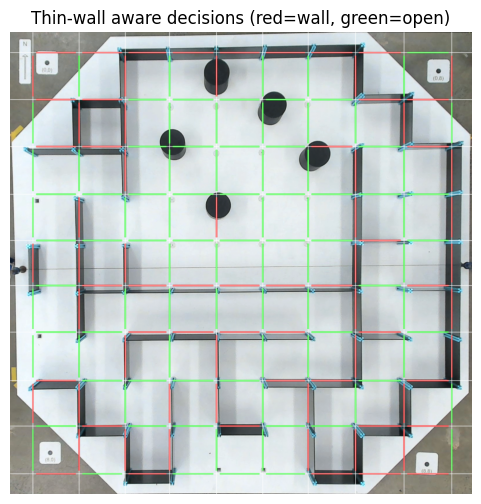

In [70]:
# Thin-wall aware wall detection using ONLY warped + your grid lines (x_lines, y_lines)

x_lines = [59, 179, 299, 414, 536, 656, 774, 897, 1023, 1147]
y_lines = [53, 175, 297, 421, 541, 658, 779, 905, 1023, 1147]

# ---- Tunables ----
EDGE_MARGIN_FRAC     = 0.08    # keep samples away from cyan posts
EDGE_THICKNESS_FRAC  = 0.3    # thickness of each sampling strip, Reduce for thinner walls ///////////////////////////////////////
OFFSETS_FRAC         = (-0.10, 0.0, +0.10)  # sample 3 strips at ±offsets of cell thickness
W_INTENSITY          = 0.1     # weight of darkness score
W_GRADIENT           = 5          # weight of orientation-aware gradient score

@dataclass
class MazeWallMap:
    N: int
    wallsN: np.ndarray
    wallsE: np.ndarray
    wallsS: np.ndarray
    wallsW: np.ndarray

def _otsu_uint8(vals_u8):
    h = np.bincount(vals_u8, minlength=256).astype(np.float64)
    p = h / (h.sum() + 1e-9)
    w = np.cumsum(p); m = np.cumsum(p*np.arange(256)); mt = m[-1]
    sb2 = (mt*w - m)**2 / (w*(1-w) + 1e-12)
    return int(np.nanargmax(sb2))

def _strip_stats(img, x1,y1,x2,y2,th):
    """Return q10 (dark) and mean of ROI. Handles axis-aligned segments."""
    H, W = img.shape
    x1=int(round(x1)); y1=int(round(y1)); x2=int(round(x2)); y2=int(round(y2))
    if x1==x2:  # vertical
        x0=max(0,x1-th//2); x1b=min(W,x2+th//2+1)
        y0=max(0,min(y1,y2)); y1b=min(H,max(y1,y2)+1)
    else:       # horizontal
        y0=max(0,y1-th//2); y1b=min(H,y2+th//2+1)
        x0=max(0,min(x1,x2)); x1b=min(W,max(x1,x2)+1)
    roi = img[y0:y1b, x0:x1b]
    if roi.size == 0: return 255.0, 255.0
    q10 = float(np.percentile(roi, 10))   # thin dark bars still show up
    mean = float(np.mean(roi))
    return q10, mean

def classify_walls_thinaware(warped, x_lines, y_lines,
                             edge_margin_frac=EDGE_MARGIN_FRAC,
                             edge_thickness_frac=EDGE_THICKNESS_FRAC,
                             offsets_frac=OFFSETS_FRAC,
                             w_int=W_INTENSITY, w_grad=W_GRADIENT):
    # Prep L* and orientation-aware gradients
    lab = cv2.cvtColor(warped, cv2.COLOR_BGR2LAB)
    L   = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)).apply(lab[:,:,0])

    # Scharr gives sharp gradients; dx for vertical edges, dy for horizontal
    Gx = cv2.Scharr(L, cv2.CV_32F, 1, 0); Gx = np.abs(Gx)
    Gy = cv2.Scharr(L, cv2.CV_32F, 0, 1); Gy = np.abs(Gy)

    xs = np.sort(np.asarray(x_lines).astype(int))
    ys = np.sort(np.asarray(y_lines).astype(int))
    N  = len(xs) - 1
    assert N == len(ys) - 1

    cell_w = float(np.median(np.diff(xs))); cell_h = float(np.median(np.diff(ys)))
    pitch  = min(cell_w, cell_h)
    thick  = max(2, int(pitch * edge_thickness_frac))
    margin = int(pitch * edge_margin_frac)
    offsets = [int(pitch * o) for o in offsets_frac]

    medL = float(np.median(L[ys[0]:ys[-1], xs[0]:xs[-1]]))

    # collect combined scores
    scores = []
    edges  = []  # (r,c,side,score)

    def edge_score(x1,y1,x2,y2,is_vertical):
        # Evaluate 3 parallel strips and take the max combined score
        best = 0.0
        for off in offsets:
            if is_vertical:
                q10, mean = _strip_stats(L, x1+off, y1, x2+off, y2, thick)
                # darker -> larger (medL - q10); use Gx (normal to vertical edge)
                g_mean = _strip_stats(Gx, x1+off, y1, x2+off, y2, thick)[1]
            else:
                q10, mean = _strip_stats(L, x1, y1+off, x2, y2+off, thick)
                # darker -> larger; use Gy (normal to horizontal edge)
                g_mean = _strip_stats(Gy, x1, y1+off, x2, y2+off, thick)[1]

            dark_score = max(0.0, medL - q10)   # percentile darkness
            comb = w_int*dark_score + w_grad*(g_mean/4.0)  # scale gradient a bit
            best = max(best, comb)
        return best

    for r in range(N):
        for c in range(N):
            xL,xR = xs[c], xs[c+1]
            yT,yB = ys[r], ys[r+1]

            sN = edge_score(xL+margin, yT, xR-margin, yT, is_vertical=False)
            sS = edge_score(xL+margin, yB, xR-margin, yB, is_vertical=False)
            sW = edge_score(xL, yT+margin, xL, yB-margin, is_vertical=True)
            sE = edge_score(xR, yT+margin, xR, yB-margin, is_vertical=True)

            for side, s in (('N',sN),('S',sS),('W',sW),('E',sE)):
                scores.append(s); edges.append((r,c,side,s))

    # Otsu on combined scores
    scores_u8 = np.clip(np.array(scores), 0, 255).astype(np.uint8)
    thr = _otsu_uint8(scores_u8)

    wallsN = np.zeros((N,N), bool); wallsE=wallsN.copy(); wallsS=wallsN.copy(); wallsW=wallsN.copy()
    for (r,c,side,s) in edges:
        is_wall = (s >= thr)
        if side=='N': wallsN[r,c]=is_wall
        elif side=='S': wallsS[r,c]=is_wall
        elif side=='W': wallsW[r,c]=is_wall
        else: wallsE[r,c]=is_wall

    # make shared edges consistent (OR)
    for r in range(N):
        for c in range(N-1):
            e = wallsE[r,c] or wallsW[r,c+1]; wallsE[r,c]=wallsW[r,c+1]=e
    for r in range(N-1):
        for c in range(N):
            e = wallsS[r,c] or wallsN[r+1,c]; wallsS[r,c]=wallsN[r+1,c]=e

    return MazeWallMap(N, wallsN, wallsE, wallsS, wallsW), {"threshold_u8": int(thr),
                                                            "margin_px": int(margin),
                                                            "thickness_px": int(thick),
                                                            "offsets_px": offsets}

# ---- run it and visualize
wallmap, params = classify_walls_thinaware(warped_norm, x_lines, y_lines)
print("params:", params)
print("wall counts N/E/S/W:", wallmap.wallsN.sum(), wallmap.wallsE.sum(), wallmap.wallsS.sum(), wallmap.wallsW.sum())

viz = warped_norm.copy()
xs = np.sort(np.asarray(x_lines).astype(int))
ys = np.sort(np.asarray(y_lines).astype(int))
margin = params["margin_px"]
for r in range(wallmap.N):
    for c in range(wallmap.N):
        xL,xR = int(xs[c]), int(xs[c+1]); yT,yB = int(ys[r]), int(ys[r+1])
        cv2.line(viz, (xL+margin,yT), (xR-margin,yT), (0,0,255) if wallmap.wallsN[r,c] else (0,255,0), 2, cv2.LINE_AA)
        cv2.line(viz, (xL+margin,yB), (xR-margin,yB), (0,0,255) if wallmap.wallsS[r,c] else (0,255,0), 2, cv2.LINE_AA)
        cv2.line(viz, (xL,yT+margin), (xL,yB-margin), (0,0,255) if wallmap.wallsW[r,c] else (0,255,0), 2, cv2.LINE_AA)
        cv2.line(viz, (xR,yT+margin), (xR,yB-margin), (0,0,255) if wallmap.wallsE[r,c] else (0,255,0), 2, cv2.LINE_AA)

# re-draw the grid (thin white) for context
for x in xs: cv2.line(viz, (int(x),0), (int(x),viz.shape[0]), (255,255,255), 1, cv2.LINE_AA)
for y in ys: cv2.line(viz, (0,int(y)), (viz.shape[1],int(y)), (255,255,255), 1, cv2.LINE_AA)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(viz, cv2.COLOR_BGR2RGB))
plt.title("Thin-wall aware decisions (red=wall, green=open)")
plt.axis('off'); plt.show()


## Continuous path planning Area

In [71]:

def bounds_from_cells(r0, c0, cells_h, cells_w, x_lines, y_lines):
    """
    r0,c0: top-left cell index (0-based)
    cells_h, cells_w: height/width in cells (e.g., 5,5)
    Returns (c_min, r_min, c_max, r_max) as indices into x_lines/y_lines.
    """
    xs = np.sort(np.asarray(x_lines).astype(int))
    ys = np.sort(np.asarray(y_lines).astype(int))
    Ncols, Nrows = len(xs)-1, len(ys)-1

    r0 = int(np.clip(r0, 0, Nrows-1))
    c0 = int(np.clip(c0, 0, Ncols-1))
    r1 = int(np.clip(r0 + cells_h, 1, Nrows))
    c1 = int(np.clip(c0 + cells_w, 1, Ncols))
    return (c0, r0, c1, r1)

def bounds_from_pixels(x1, y1, x2, y2, x_lines, y_lines, min_cells=None):
    """
    x1,y1,x2,y2 in pixels (any order). Snaps to nearest grid lines.
    Optional min_cells enforces a minimum size (e.g., 5).
    """
    xs = np.sort(np.asarray(x_lines).astype(int))
    ys = np.sort(np.asarray(y_lines).astype(int))
    Ncols, Nrows = len(xs)-1, len(ys)-1

    xL, xR = (min(x1,x2), max(x1,x2))
    yT, yB = (min(y1,y2), max(y1,y2))

    c_min = int(np.searchsorted(xs, xL, side="right") - 1); c_min = np.clip(c_min, 0, Ncols-1)
    c_max = int(np.searchsorted(xs, xR, side="right"));     c_max = np.clip(c_max, c_min+1, Ncols)
    r_min = int(np.searchsorted(ys, yT, side="right") - 1); r_min = np.clip(r_min, 0, Nrows-1)
    r_max = int(np.searchsorted(ys, yB, side="right"));     r_max = np.clip(r_max, r_min+1, Nrows)

    if min_cells is not None:
        def expand(lo, hi, need, limit):
            size = hi - lo
            if size >= need: return lo, hi
            deficit = need - size
            growL = (deficit + 1)//2; growR = deficit - growL
            lo = max(0, lo - growL); hi = min(limit, hi + growR)
            if hi - lo < need:  # push the other side if clamped
                rem = need - (hi - lo)
                if lo == 0: hi = min(limit, hi + rem)
                else:       lo = max(0, lo - rem)
            return lo, hi

        c_min, c_max = expand(c_min, c_max, min_cells, Ncols)
        r_min, r_max = expand(r_min, r_max, min_cells, Nrows)

    return (c_min, r_min, c_max, r_max)

def visualize_bounds(warped_bgr, x_lines, y_lines, bounds, title="Manual bounds"):
    xs = np.sort(np.asarray(x_lines).astype(int))
    ys = np.sort(np.asarray(y_lines).astype(int))
    c0,r0,c1,r1 = bounds
    xA, xB = xs[c0], xs[c1]
    yA, yB = ys[r0], ys[r1]

    vis = warped_bgr.copy()
    ov  = vis.copy()
    cv2.rectangle(ov, (xA,yA), (xB,yB), (0,255,255), -1)           # yellow fill
    vis = cv2.addWeighted(ov, 0.18, vis, 0.82, 0)
    cv2.rectangle(vis, (xA,yA), (xB,yB), (0,255,255), 3, cv2.LINE_AA)

    # optional: grid lines for context
    for x in xs: cv2.line(vis, (x,0), (x,vis.shape[0]), (255,255,255), 1, cv2.LINE_AA)
    for y in ys: cv2.line(vis, (0,y), (vis.shape[1],y), (255,255,255), 1, cv2.LINE_AA)

    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.title(f"{title}  bounds={bounds}")
    plt.axis('off'); plt.show()


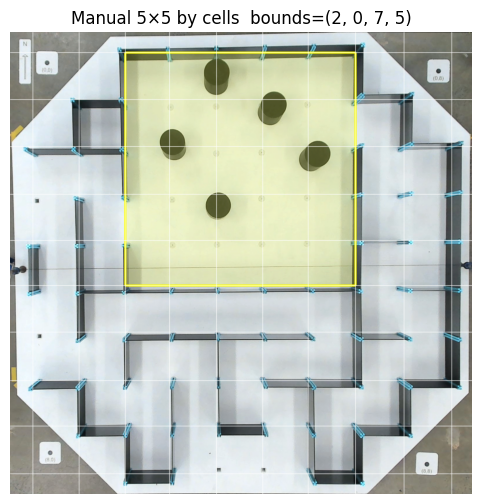

In [72]:
# e.g., top-left cell (row=2, col=3), 5×5 window
bounds = bounds_from_cells(r0=0, c0=2, cells_h=5, cells_w=5, x_lines=x_lines, y_lines=y_lines) # Bounds for the continuous area
visualize_bounds(warped_norm, x_lines, y_lines, bounds, "Manual 5×5 by cells")

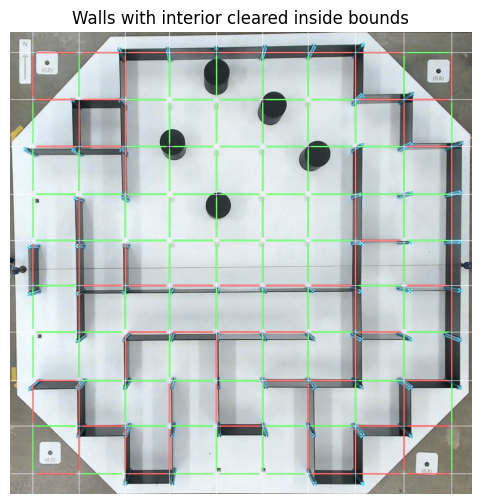

In [73]:
# --- Remove (ignore) walls *inside* the given bounds; keep the perimeter walls intact ---
from copy import deepcopy
import numpy as np, cv2, matplotlib.pyplot as plt

def clear_walls_inside_bounds(wmap, bounds, keep_perimeter=True):
    """
    wmap: MazeWallMap(N, wallsN, wallsE, wallsS, wallsW) from your thin-wall detector
    bounds: (c0, r0, c1, r1) indexing into grid lines (cells inside are r0..r1-1, c0..c1-1)
    keep_perimeter=True -> only clear interior edges; boundary edges remain as detected
    """
    w = deepcopy(wmap)
    c0, r0, c1, r1 = map(int, bounds)
    N = int(w.N)

    # clamp & normalize
    c0 = max(0, min(c0, N-1)); c1 = max(1, min(c1, N))
    r0 = max(0, min(r0, N-1)); r1 = max(1, min(r1, N))
    if c1 <= c0 or r1 <= r0:
        return w  # nothing to do

    for r in range(r0, r1):
        for c in range(c0, c1):
            # edges belonging to cell (r,c)
            # interior tests so we *don't* touch the perimeter when keep_perimeter=True
            if (not keep_perimeter) or (r > r0):        w.wallsN[r, c] = False  # north edge
            if (not keep_perimeter) or (r < r1 - 1):    w.wallsS[r, c] = False  # south edge
            if (not keep_perimeter) or (c > c0):        w.wallsW[r, c] = False  # west edge
            if (not keep_perimeter) or (c < c1 - 1):    w.wallsE[r, c] = False  # east edge

    # re-enforce shared-edge consistency
    for rr in range(N):
        for cc in range(N-1):
            e = w.wallsE[rr, cc] or w.wallsW[rr, cc+1]
            w.wallsE[rr, cc] = w.wallsW[rr, cc+1] = e
    for rr in range(N-1):
        for cc in range(N):
            s = w.wallsS[rr, cc] or w.wallsN[rr+1, cc]
            w.wallsS[rr, cc] = w.wallsN[rr+1, cc] = s

    return w

# ---- apply it ----
# assumes you already have: wallmap (from classify_walls_thinaware), x_lines, y_lines, bounds
wallmap_inside_cleared = clear_walls_inside_bounds(wallmap, bounds, keep_perimeter=True)

# ---- quick visualization using your existing style (red=wall, green=open) ----
xs = np.sort(np.asarray(x_lines).astype(int))
ys = np.sort(np.asarray(y_lines).astype(int))
viz = warped_norm.copy()
margin =  max(1, int(0.08 * min(np.median(np.diff(xs)), np.median(np.diff(ys)))))

for r in range(wallmap_inside_cleared.N):
    for c in range(wallmap_inside_cleared.N):
        xL,xR = int(xs[c]), int(xs[c+1])
        yT,yB = int(ys[r]), int(ys[r+1])
        cv2.line(viz, (xL+margin,yT), (xR-margin,yT),
                 (0,0,255) if wallmap_inside_cleared.wallsN[r,c] else (0,255,0), 2, cv2.LINE_AA)
        cv2.line(viz, (xL+margin,yB), (xR-margin,yB),
                 (0,0,255) if wallmap_inside_cleared.wallsS[r,c] else (0,255,0), 2, cv2.LINE_AA)
        cv2.line(viz, (xL,yT+margin), (xL,yB-margin),
                 (0,0,255) if wallmap_inside_cleared.wallsW[r,c] else (0,255,0), 2, cv2.LINE_AA)
        cv2.line(viz, (xR,yT+margin), (xR,yB-margin),
                 (0,0,255) if wallmap_inside_cleared.wallsE[r,c] else (0,255,0), 2, cv2.LINE_AA)

# draw grid for context
for x in xs: cv2.line(viz, (x,0), (x,viz.shape[0]), (255,255,255), 1, cv2.LINE_AA)
for y in ys: cv2.line(viz, (0,y), (viz.shape[1],y), (255,255,255), 1, cv2.LINE_AA)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(viz, cv2.COLOR_BGR2RGB))
plt.title("Walls with interior cleared inside bounds")
plt.axis('off'); plt.show()


## 6. Logical maze extract

In [74]:
def make_collision_mask_from_red(walls_bgr, dilate_px=1):
    b,g,r = cv2.split(walls_bgr)
    redish = (r >= 200) & (g <= 30) & (b <= 30)
    mask = (redish.astype(np.uint8) * 255)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((3,3),np.uint8), 1)
    if dilate_px > 0:
        mask = cv2.dilate(mask, np.ones((dilate_px, dilate_px), np.uint8), 1)
    return mask

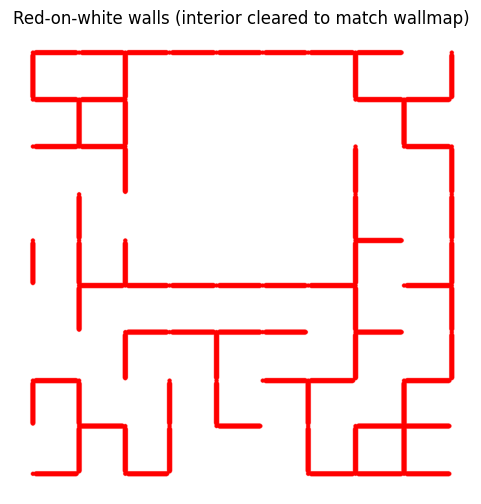

In [75]:
# --- Re-render red-on-white image from the (inside-cleared) wall map ---
import numpy as np, cv2, matplotlib.pyplot as plt

def render_walls_red_on_white(warped_bgr, x_lines, y_lines, wmap,
                              thickness_frac=0.08,   # wall thickness vs pitch
                              margin_frac=0.06,      # keep lines away from posts a bit
                              draw_connectors=True):
    """
    Returns a fresh BGR image with pure red walls on white background,
    rendered from the boolean wall map (N/E/S/W).
    """
    H, W = warped_bgr.shape[:2]
    xs = np.sort(np.asarray(x_lines).astype(int))
    ys = np.sort(np.asarray(y_lines).astype(int))
    pitch = float(min(np.median(np.diff(xs)), np.median(np.diff(ys))))

    t = max(2, int(round(thickness_frac * pitch))) | 1
    m = max(0, int(round(margin_frac    * pitch)))
    red = (0, 0, 255)

    out = np.full((H, W, 3), 255, np.uint8)  # white background

    # draw walls from the map
    for r in range(wmap.N):
        for c in range(wmap.N):
            xL, xR = int(xs[c]),   int(xs[c+1])
            yT, yB = int(ys[r]),   int(ys[r+1])

            if wmap.wallsN[r, c]:
                cv2.line(out, (xL + m, yT), (xR - m, yT), red, t, cv2.LINE_AA)
            if wmap.wallsS[r, c]:
                cv2.line(out, (xL + m, yB), (xR - m, yB), red, t, cv2.LINE_AA)
            if wmap.wallsW[r, c]:
                cv2.line(out, (xL, yT + m), (xL, yB - m), red, t, cv2.LINE_AA)
            if wmap.wallsE[r, c]:
                cv2.line(out, (xR, yT + m), (xR, yB - m), red, t, cv2.LINE_AA)

    if draw_connectors:
        # draw small disks at intersections that touch any wall to prevent pinholes
        rad = max(1, t // 2)
        for i, y in enumerate(ys):
            for j, x in enumerate(xs):
                touch = False
                # north: cell (i-1, j)
                if i-1 >= 0 and j < wmap.N and wmap.wallsS[i-1, j]: touch = True
                # south: cell (i, j)
                if i < wmap.N and j < wmap.N and wmap.wallsN[i, j]: touch = True
                # west:  cell (i, j-1)
                if j-1 >= 0 and i < wmap.N and wmap.wallsE[i, j-1]: touch = True
                # east:  cell (i, j)
                if j < wmap.N and i < wmap.N and wmap.wallsW[i, j]: touch = True
                if touch:
                    cv2.circle(out, (int(x), int(y)), rad, red, -1, cv2.LINE_AA)

    return out

# ---- apply: rebuild walls_white to match 'wallmap_inside_cleared' ----
walls_white = render_walls_red_on_white(
    warped_norm, x_lines, y_lines, wallmap_inside_cleared,
    thickness_frac=0.08,   # tweak 0.06–0.12 for your visual
    margin_frac=0.06,
    draw_connectors=True
)

# update your collision mask if you rely on walls_white for planning
# collide = make_collision_mask_from_red(walls_white, dilate_px=dilate_px)

# preview
plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(walls_white, cv2.COLOR_BGR2RGB))
plt.title("Red-on-white walls (interior cleared to match wallmap)")
plt.axis('off'); plt.show()


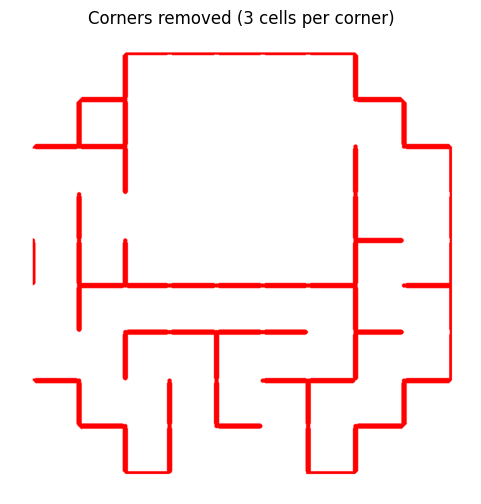

In [76]:
# Remove the 3-cell corner triangles from the walls image (and rebuild collide)
import numpy as np, cv2, matplotlib.pyplot as plt

# how many grid intervals to go in from each corner to define the triangle
# 3 corner cells -> depth of 2 intervals
CORNER_DEPTH = 2   # change to 3, 4... if you ever need a larger cut

def cut_corner_triangles(walls_bgr, x_lines, y_lines, depth=2):
    xs = np.asarray(x_lines, dtype=int)
    ys = np.asarray(y_lines, dtype=int)
    H, W = walls_bgr.shape[:2]

    k = int(depth)
    # triangles in TL / TR / BL / BR corners defined by grid intersections
    tl = np.array([[xs[0],   ys[0]],
                   [xs[k],   ys[0]],
                   [xs[0],   ys[k]]], np.int32)

    tr = np.array([[xs[-1],  ys[0]],
                   [xs[-1-k],ys[0]],
                   [xs[-1],  ys[k]]], np.int32)

    bl = np.array([[xs[0],   ys[-1]],
                   [xs[k],   ys[-1]],
                   [xs[0],   ys[-1-k]]], np.int32)

    br = np.array([[xs[-1],  ys[-1]],
                   [xs[-1-k],ys[-1]],
                   [xs[-1],  ys[-1-k]]], np.int32)

    # build a keep mask = board rectangle minus corner triangles
    keep = np.zeros((H, W), np.uint8)
    cv2.rectangle(keep, (xs[0], ys[0]), (xs[-1], ys[-1]), 255, -1)
    cv2.fillPoly(keep, [tl, tr, bl, br], 0)  # punch out triangles

    # apply to walls: anything outside keep -> set to white
    out = walls_bgr.copy()
    out[keep == 0] = (255, 255, 255)
    return out, keep

# --- apply ---
walls_white, keep_mask = cut_corner_triangles(walls_white, x_lines, y_lines, depth=CORNER_DEPTH)


# quick preview
plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(walls_white, cv2.COLOR_BGR2RGB))
plt.title("Corners removed (3 cells per corner)")
plt.axis('off'); plt.show()


## Crop out and focus on only Continuous part

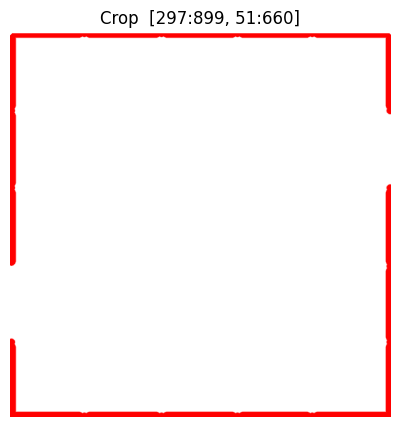

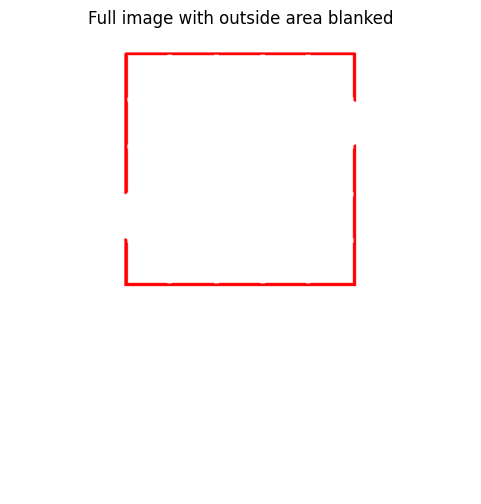

In [77]:
# --- Extract only the bounding-box part of the image (crop or masked) ---
def bbox_pixels_from_bounds(x_lines, y_lines, bounds, pad_px=0, image_shape=None):
    """
    Convert grid bounds -> pixel box. Optionally pad and clamp to image.
    bounds: (c_min, r_min, c_max, r_max) indices into x_lines/y_lines (right/bottom are exclusive).
    pad_px: extra pixels around all sides (after snapping).
    image_shape: (H,W,...) to clamp within image size; pass None to skip clamping.
    Returns (x1, y1, x2, y2) with x2/y2 exclusive (Python slicing friendly).
    """
    xs = np.sort(np.asarray(x_lines).astype(int))
    ys = np.sort(np.asarray(y_lines).astype(int))
    c0, r0, c1, r1 = map(int, bounds)
    # snap to grid lines
    x1, x2 = xs[c0], xs[c1]
    y1, y2 = ys[r0], ys[r1]
    # add padding
    x1 -= pad_px; y1 -= pad_px; x2 += pad_px; y2 += pad_px
    # clamp if image shape provided
    if image_shape is not None:
        H, W = image_shape[:2]
        x1 = max(0, min(x1, W-1))
        y1 = max(0, min(y1, H-1))
        x2 = max(1, min(x2, W))
        y2 = max(1, min(y2, H))
    return int(x1), int(y1), int(x2), int(y2)

def crop_by_bounds(img_bgr, x_lines, y_lines, bounds, pad_px=0):
    """Return tight crop (subimage) of the bounds (with optional padding)."""
    x1, y1, x2, y2 = bbox_pixels_from_bounds(x_lines, y_lines, bounds, pad_px, img_bgr.shape)
    return img_bgr[y1:y2, x1:x2].copy(), (x1, y1, x2, y2)

def mask_outside_bounds(img_bgr, x_lines, y_lines, bounds, pad_px=0, bg_color=(255,255,255)):
    """
    Return full-size image where everything outside the bounds is set to bg_color (BGR).
    """
    x1, y1, x2, y2 = bbox_pixels_from_bounds(x_lines, y_lines, bounds, pad_px, img_bgr.shape)
    out = img_bgr.copy()
    mask = np.zeros(img_bgr.shape[:2], np.uint8)
    cv2.rectangle(mask, (x1, y1), (x2-1, y2-1), 255, -1)
    # set outside to bg_color
    outside = (mask == 0)
    if img_bgr.ndim == 3:
        out[outside] = bg_color
    else:
        # grayscale
        out[outside] = bg_color if isinstance(bg_color, (int, np.integer)) else 255
    return out, (x1, y1, x2, y2)

# ---------- example usage ----------
# choose which image you want to extract from:
src_img = walls_white        # or warped_norm, warped, etc.

# optional padding as a fraction of grid pitch
xs = np.sort(np.asarray(x_lines).astype(int))
ys = np.sort(np.asarray(y_lines).astype(int))
pitch = float(min(np.median(np.diff(xs)), np.median(np.diff(ys))))
pad_px = int(0.02 * pitch)   # ~2% of a cell; set 0 for no pad

# 1) tight crop
crop, (x1,y1,x2,y2) = crop_by_bounds(src_img, x_lines, y_lines, bounds, pad_px=pad_px)
plt.figure(figsize=(5,5)); plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)); plt.axis('off')
plt.title(f"Crop  [{x1}:{x2}, {y1}:{y2}]"); plt.show()

# 2) full-size with outside set to white
masked, _ = mask_outside_bounds(src_img, x_lines, y_lines, bounds, pad_px=pad_px, bg_color=(255,255,255))
plt.figure(figsize=(6,6)); plt.imshow(cv2.cvtColor(masked, cv2.COLOR_BGR2RGB)); plt.axis('off')
plt.title("Full image with outside area blanked"); plt.show()


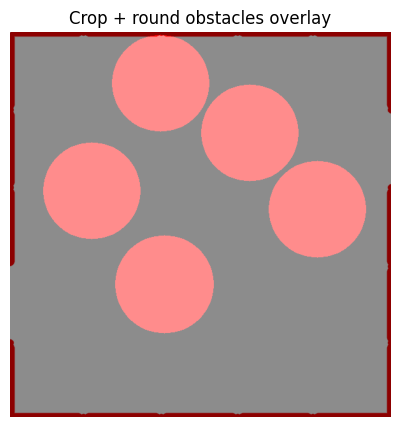

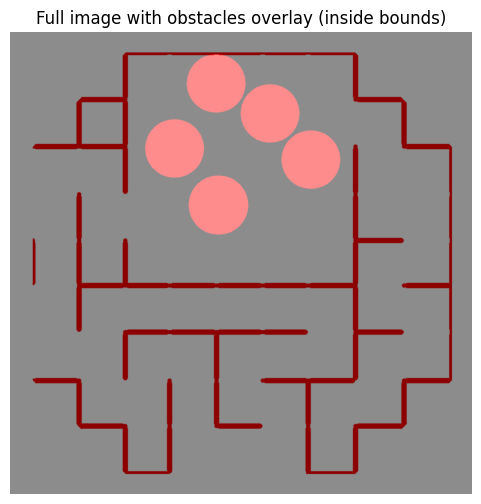

In [78]:
# --- Overlay the round obstacles mask onto the crop and/or the full image ---
# choose the source image to show (red-on-white walls looks nice)
src_img = walls_white  # or warped_norm

# get pixel box of the bounds (reuse the helper from previous cell)
x1, y1, x2, y2 = bbox_pixels_from_bounds(x_lines, y_lines, bounds, pad_px=0, image_shape=src_img.shape)

# pick the mask variable you have:
#   - prefer full-size mask if available (e.g., cylinder_unsafe_mask)
#   - else fall back to local 'mask' returned by circle_mask_fixed_radius on the crop
mask_full = None
if 'cylinder_unsafe_mask' in globals() and cylinder_unsafe_mask is not None:
    mask_full = cylinder_unsafe_mask
elif 'mask_dilated' in globals() and mask_dilated is not None:
    mask_full = mask_dilated

# Build crop image and crop mask
crop = src_img[y1:y2, x1:x2].copy()

if mask_full is not None and mask_full.shape[:2] == src_img.shape[:2]:
    crop_mask = mask_full[y1:y2, x1:x2]
else:
    # assume you have a crop-sized mask variable named 'mask'
    assert 'mask' in globals(), "Provide either a full-size mask (cylinder_unsafe_mask) or a crop mask named 'mask'."
    crop_mask = mask
    # sanity check
    if crop_mask.shape[:2] != crop.shape[:2]:
        raise ValueError(f"crop mask shape {crop_mask.shape} does not match crop {crop.shape}")

# -------- overlay on crop (green, semi-transparent) --------
alpha = 0.45
color_bgr = (0, 0, 255)      # green in BGR
color_layer_crop = np.zeros_like(crop)
color_layer_crop[crop_mask > 0] = color_bgr
crop_overlay = cv2.addWeighted(color_layer_crop, alpha, crop, 1 - alpha, 0)

plt.figure(figsize=(5,5))
plt.imshow(cv2.cvtColor(crop_overlay, cv2.COLOR_BGR2RGB))
plt.title("Crop + round obstacles overlay")
plt.axis('off'); plt.show()

# -------- overlay on full-size (only inside bounds) --------
full_overlay = src_img.copy()
color_layer_full = np.zeros_like(full_overlay)
color_layer_full[y1:y2, x1:x2][crop_mask > 0] = color_bgr
full_overlay = cv2.addWeighted(color_layer_full, alpha, full_overlay, 1 - alpha, 0)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(full_overlay, cv2.COLOR_BGR2RGB))
plt.title("Full image with obstacles overlay (inside bounds)")
plt.axis('off'); plt.show()

# keep the crop-sized mask to feed your planner inside the box
occ_mask_crop = crop_mask.copy()   # 255 = obstacle


## CONTINUOUS PATH PLANNING

In [79]:
# Start and end cells for the continuous parts
start_cell_rc = (1, 6)
goal_cell_rc = (3,2)

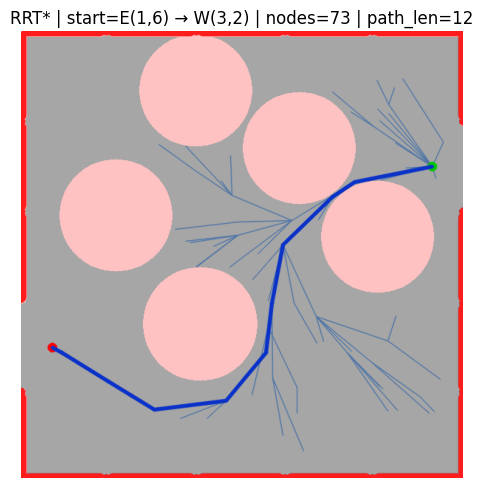

[{'side': 'W', 'r': 3, 'c': 2, 'pt_px': (341, 481)}, {'side': 'E', 'r': 1, 'c': 6, 'pt_px': (855, 236)}]


In [80]:
# ========= RRT* on the 5×5 obstacle window (strict start/end by cell) =========
import random
from collections import deque

# ---------- required globals ----------
# expects you already have: walls_white (BGR), x_lines, y_lines, bounds
# and a wall map: wallmap_inside_cleared (preferred) or wallmap
# and an obstacle mask for cylinders inside the bounds crop: occ_mask_crop (optional)

# ---------- user MUST set these two (GLOBAL grid indices, 0..N-1) ----------
# e.g. start at border cell (row=5, col=6) and goal at (row=5, col=8)
# start_cell_rc = (5, 6)
# goal_cell_rc  = (5, 8)

# ---------- helper: pixel box from bounds ----------
def bbox_pixels_from_bounds(x_lines, y_lines, bounds, pad_px=0, image_shape=None):
    xs = np.sort(np.asarray(x_lines).astype(int))
    ys = np.sort(np.asarray(y_lines).astype(int))
    c0, r0, c1, r1 = map(int, bounds)
    x1, x2 = xs[c0], xs[c1]
    y1, y2 = ys[r0], ys[r1]
    x1 -= pad_px; y1 -= pad_px; x2 += pad_px; y2 += pad_px
    if image_shape is not None:
        H, W = image_shape[:2]
        x1 = max(0, min(x1, W-1)); y1 = max(0, min(y1, H-1))
        x2 = max(1, min(x2, W));   y2 = max(1, min(y2, H))
    return int(x1), int(y1), int(x2), int(y2)

# ---------- ensure we can make a collision mask from red walls ----------
if 'make_collision_mask_from_red' not in globals():
    def make_collision_mask_from_red(walls_bgr, dilate_px=1):
        b,g,r = cv2.split(walls_bgr)
        redish = (r >= 200) & (g <= 30) & (b <= 30)
        mask = (redish.astype(np.uint8) * 255)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((3,3),np.uint8), 1)
        if dilate_px > 0:
            mask = cv2.dilate(mask, np.ones((dilate_px, dilate_px), np.uint8), 1)
        return mask

# ---------- make collision mask inside the bounds ----------
def make_collision_mask_for_window(walls_white_bgr, x_lines, y_lines, bounds, occ_mask_crop=None, dilate_px=2):
    wall_mask_full = make_collision_mask_from_red(walls_white_bgr, dilate_px=max(1, dilate_px))
    x1, y1, x2, y2 = bbox_pixels_from_bounds(x_lines, y_lines, bounds, image_shape=walls_white_bgr.shape)
    crop_wall = wall_mask_full[y1:y2, x1:x2].copy()
    if occ_mask_crop is None:
        occ_mask_crop = np.zeros_like(crop_wall)
    else:
        occ_mask_crop = ((occ_mask_crop > 0)*255).astype(np.uint8)
        if occ_mask_crop.shape[:2] != crop_wall.shape[:2]:
            raise ValueError(f"occ_mask_crop shape {occ_mask_crop.shape} != crop size {crop_wall.shape}")
    occ = cv2.bitwise_or(crop_wall, occ_mask_crop)  # walls ∪ cylinders
    return occ, (x1, y1, x2, y2)

# ---------- find the two openings on the box perimeter ----------
def find_perimeter_openings(wmap, bounds, x_lines, y_lines, inward_frac=0.35):
    xs = np.sort(np.asarray(x_lines).astype(int))
    ys = np.sort(np.asarray(y_lines).astype(int))
    c0, r0, c1, r1 = map(int, bounds)
    pitch = float(min(np.median(np.diff(xs)), np.median(np.diff(ys))))
    inward = int(round(inward_frac * pitch))  # step inside free space

    openings = []
    # Top
    for c in range(c0, c1):
        if not wmap.wallsN[r0, c]:
            x = int(0.5*(xs[c] + xs[c+1])); y = int(ys[r0] + inward)
            openings.append(dict(side='N', r=r0,   c=c, pt_px=(x,y)))
    # Bottom
    for c in range(c0, c1):
        if not wmap.wallsS[r1-1, c]:
            x = int(0.5*(xs[c] + xs[c+1])); y = int(ys[r1] - inward)
            openings.append(dict(side='S', r=r1-1, c=c, pt_px=(x,y)))
    # Left
    for r in range(r0, r1):
        if not wmap.wallsW[r, c0]:
            x = int(xs[c0] + inward); y = int(0.5*(ys[r] + ys[r+1]))
            openings.append(dict(side='W', r=r, c=c0,   pt_px=(x,y)))
    # Right
    for r in range(r0, r1):
        if not wmap.wallsE[r, c1-1]:
            x = int(xs[c1] - inward); y = int(0.5*(ys[r] + ys[r+1]))
            openings.append(dict(side='E', r=r, c=c1-1, pt_px=(x,y)))

    if len(openings) != 2:
        print(f"[warn] expected 2 openings, found {len(openings)} → {[(o['side'],o['r'],o['c']) for o in openings]}")
    return openings

# ---------- STRICT mapping from (row,col) to an opening ----------
def opening_for_cell_strict(openings, cell_rc, bounds):
    sr, sc = map(int, cell_rc)
    c0, r0, c1, r1 = map(int, bounds)
    on_perimeter = (sr == r0) or (sr == r1-1) or (sc == c0) or (sc == c1-1)
    if not on_perimeter:
        raise ValueError(
            f"Cell {cell_rc} is not on the perimeter of the window "
            f"(rows [{r0},{r1-1}] or cols [{c0},{c1-1}])."
        )
    for op in openings:
        if op['r'] == sr and op['c'] == sc:
            return op
    avail = sorted([(op['side'], op['r'], op['c']) for op in openings])
    raise ValueError(f"No opening at cell {cell_rc}. Available openings: {avail}")

# ---------- geometry helpers ----------
def line_collision(mask, p, q):
    """True if segment p->q hits an obstacle in mask (mask>0)."""
    x1,y1 = map(int, p); x2,y2 = map(int, q)
    dx = abs(x2 - x1); dy = abs(y2 - y1)
    sx = 1 if x1 < x2 else -1; sy = 1 if y1 < y2 else -1
    err = dx - dy
    x, y = x1, y1
    H, W = mask.shape
    while True:
        if x < 0 or y < 0 or x >= W or y >= H: return True
        if mask[y, x] != 0: return True
        if x == x2 and y == y2: break
        e2 = 2*err
        if e2 > -dy: err -= dy; x += sx
        if e2 <  dx: err += dx; y += sy
    return False

def steer(p, q, eta):
    """Move from p toward q by at most eta pixels."""
    px,py = p; qx,qy = q
    vx, vy = qx-px, qy-py
    L = math.hypot(vx, vy)
    if L <= eta: return (int(qx), int(qy))
    s = eta / (L + 1e-9)
    return (int(px + s*vx), int(py + s*vy))

# ---------- RRT* ----------
class RRTStar:
    def __init__(self, mask, start, goal, step, goal_radius, rewire_radius, max_iter=4000, goal_bias=0.12):
        self.mask = mask
        self.H, self.W = mask.shape
        self.start = tuple(map(int, start))
        self.goal  = tuple(map(int, goal))
        self.step = int(step)
        self.goal_radius = int(goal_radius)
        self.rewire_radius = int(rewire_radius)
        self.max_iter = int(max_iter)
        self.goal_bias = float(goal_bias)

        self.nodes = [self.start]
        self.parent = {self.start: None}
        self.cost   = {self.start: 0.0}

    def sample(self):
        if random.random() < self.goal_bias:
            return self.goal
        return (random.randint(0, self.W-1), random.randint(0, self.H-1))

    def nearest(self, x):
        bx,by = x
        best = None; bestd2 = 1e18
        for n in self.nodes:
            dx = n[0]-bx; dy = n[1]-by
            d2 = dx*dx + dy*dy
            if d2 < bestd2:
                bestd2 = d2; best = n
        return best

    def near(self, x, radius):
        r2 = radius*radius
        out = []
        for n in self.nodes:
            dx = n[0]-x[0]; dy = n[1]-x[1]
            if dx*dx + dy*dy <= r2:
                out.append(n)
        return out

    def run(self):
        reached = None
        for _ in range(self.max_iter):
            rnd = self.sample()
            nearest = self.nearest(rnd)
            new = steer(nearest, rnd, self.step)
            if line_collision(self.mask, nearest, new):  # blocked
                continue

            # choose parent
            best_parent = nearest
            best_cost   = self.cost[nearest] + math.dist(nearest, new)
            for nb in self.near(new, self.rewire_radius):
                c = self.cost[nb] + math.dist(nb, new)
                if c < best_cost and not line_collision(self.mask, nb, new):
                    best_cost, best_parent = c, nb

            self.nodes.append(new)
            self.parent[new] = best_parent
            self.cost[new]   = best_cost

            # rewire
            for nb in self.near(new, self.rewire_radius):
                c = self.cost[new] + math.dist(new, nb)
                if c + 1e-9 < self.cost.get(nb, 1e18) and not line_collision(self.mask, new, nb):
                    self.parent[nb] = new
                    self.cost[nb]   = c

            # goal check
            if math.dist(new, self.goal) <= self.goal_radius and not line_collision(self.mask, new, self.goal):
                self.parent[self.goal] = new
                self.cost[self.goal]   = self.cost[new] + math.dist(new, self.goal)
                reached = self.goal
                break

        # reconstruct path
        if reached is None:
            best = min(self.nodes, key=lambda n: math.dist(n, self.goal))
            if not line_collision(self.mask, best, self.goal):
                self.parent[self.goal] = best
                reached = self.goal
        if reached is None:
            return []
        path = []
        n = reached
        while n is not None:
            path.append(n)
            n = self.parent[n]
        path.reverse()
        return path

# ====== Build the crop + occ mask + openings ======
occ_mask_window, (x1,y1,x2,y2) = make_collision_mask_for_window(
    walls_white, x_lines, y_lines, bounds,
    occ_mask_crop=occ_mask_crop if 'occ_mask_crop' in globals() else None,
    dilate_px=2
)
crop_rgb = cv2.cvtColor(walls_white[y1:y2, x1:x2], cv2.COLOR_BGR2RGB)

# Openings on the perimeter (use cleared map if available)
wmap_for_openings = wallmap_inside_cleared if 'wallmap_inside_cleared' in globals() else wallmap
openings = find_perimeter_openings(wmap_for_openings, bounds, x_lines, y_lines, inward_frac=0.35)

# --- STRICT: choose openings from EXACT user (row,col) cells on the window perimeter ---
if 'start_cell_rc' not in globals() or 'goal_cell_rc' not in globals():
    raise RuntimeError("Define start_cell_rc and goal_cell_rc as (row, col) in GLOBAL grid before running.")
start_op = opening_for_cell_strict(openings, start_cell_rc, bounds)
goal_op  = opening_for_cell_strict(openings, goal_cell_rc,  bounds)

# convert to local crop coordinates
sx, sy = start_op['pt_px']; gx, gy = goal_op['pt_px']
start_local = (sx - x1, sy - y1)
goal_local  = (gx - x1, gy - y1)

# ====== RRT* parameters (based on grid pitch) ======
xs = np.sort(np.asarray(x_lines).astype(int))
ys = np.sort(np.asarray(y_lines).astype(int))
pitch = float(min(np.median(np.diff(xs)), np.median(np.diff(ys))))

step          = max(8, int(0.30 * pitch))
rewire_radius = max(20, int(0.90 * pitch))
goal_radius   = max(10, int(0.35 * pitch))
max_iter      = 4500

planner = RRTStar(occ_mask_window, start_local, goal_local,
                  step=step, goal_radius=goal_radius,
                  rewire_radius=rewire_radius, max_iter=max_iter, goal_bias=0.15)
path = planner.run()

# ====== visualize ======
viz = crop_rgb.copy()

# draw a faint tree
for child, parent in planner.parent.items():
    if parent is None: continue
    cv2.line(viz, parent, child, (120, 180, 255), 1, cv2.LINE_AA)

# overlay obstacles (semi-red)
layer = np.zeros_like(viz)
layer[occ_mask_window > 0] = (255, 80, 80)
viz = cv2.addWeighted(layer, 0.35, viz, 0.65, 0)

# start/goal markers
cv2.circle(viz, start_local, 6, (0, 200, 0), -1, cv2.LINE_AA)
cv2.circle(viz, goal_local,  6, (255, 0, 0), -1, cv2.LINE_AA)

# path
if len(path) > 1:
    for i in range(len(path)-1):
        cv2.line(viz, path[i], path[i+1], (10, 50, 200), 4, cv2.LINE_AA)

plt.figure(figsize=(5.8,5.8))
plt.imshow(viz); plt.axis('off')
plt.title(f"RRT* | start={start_op['side']}({start_op['r']},{start_op['c']}) → "
          f"{goal_op['side']}({goal_op['r']},{goal_op['c']}) | nodes={len(planner.nodes)} | path_len={len(path)}")
plt.show()

print(openings)

In [81]:
# ==== Path → A(angle)F(distance) commands ====================================

def _angle_deg_from_vec(dx, dy):
    """
    Heading angle in degrees with +x to the right, +y up (math coords).
    Our image has +y down, so flip dy sign here.
    """
    return math.degrees(math.atan2(-(dy), dx))  # +CCW

def _normalize_angle_deg(a):
    """Wrap angle to (-180, 180]."""
    a = (a + 180.0) % 360.0 - 180.0
    return a if a != -180.0 else 180.0

def _rdp(points, eps):
    """Ramer–Douglas–Peucker in pixels; points: [(x,y),...]"""
    if len(points) <= 2 or eps <= 0:
        return points[:]
    P = np.asarray(points, dtype=float)
    a, b = P[0], P[-1]
    ab = b - a
    ab2 = (ab**2).sum()
    if ab2 == 0:
        idx = 0; dmax = 0.0
    else:
        # perpendicular distance of each point to segment a-b
        t = np.clip(((P - a) @ ab) / ab2, 0, 1)
        proj = a + np.outer(t, ab)
        d = np.linalg.norm(P - proj, axis=1)
        idx = int(np.argmax(d)); dmax = float(d[idx])
    if dmax > eps:
        left  = _rdp(points[:idx+1], eps)
        right = _rdp(points[idx:], eps)
        return left[:-1] + right
    else:
        return [tuple(map(float, a)), tuple(map(float, b))]

def _initial_heading_from_opening(side):
    """
    Robot points INWARD from the box boundary:
      W-side opening -> heading +x  (0°)
      E-side opening -> heading -x  (±180°)
      N-side opening -> heading +y  (down in image -> -90° here)
      S-side opening -> heading -y  (+90° here)
    """
    return {'W': 0.0, 'E': 180.0, 'N': -90.0, 'S': 90.0}[side]

def path_to_AF_commands(
    path_xy,
    start_side,
    px_to_mm,
    eps_simplify_px=4.0,
    min_seg_mm=2.0,
    min_turn_deg=0.8,
    round_dist_mm=1,     # round forward distance to nearest mm
    round_angle_deg=1    # round angle to nearest degree
):
    """
    Returns: commands_str, cmds_list
      commands_str: e.g. "A(-20)F(55)A(35)F(120)"
      cmds_list: list of dicts [{ 'A': ang_deg, 'F': dist_mm }, ...]
    """
    if path_xy is None or len(path_xy) < 2:
        return "", []

    # 1) simplify path
    simp = _rdp([tuple(map(float, p)) for p in path_xy], eps_simplify_px)
    if len(simp) < 2: 
        return "", []

    # 2) walk segments
    hdg = _initial_heading_from_opening(start_side)
    cmds = []

    for i in range(len(simp) - 1):
        x1, y1 = simp[i]
        x2, y2 = simp[i+1]
        dx, dy = (x2 - x1), (y2 - y1)
        seg_len_px = math.hypot(dx, dy)
        if seg_len_px * px_to_mm < min_seg_mm:
            continue

        seg_hdg = _angle_deg_from_vec(dx, dy)
        turn = _normalize_angle_deg(seg_hdg - hdg)

        # Only emit a turn if it matters
        if abs(turn) >= min_turn_deg:
            cmds.append({'A': round(turn, round_angle_deg), 'F': None})
            hdg = _normalize_angle_deg(hdg + turn)

        dist_mm = seg_len_px * px_to_mm
        cmds.append({'A': 0, 'F': int(round(dist_mm / round_dist_mm) * round_dist_mm)})

    # 3) compress: merge consecutive A(0)F + A(0)F
    merged = []
    for c in cmds:
        if merged and c['A'] == 0 and c['F'] is not None and merged[-1]['A'] == 0:
            merged[-1]['F'] += c['F']
        else:
            merged.append(c)

    # 4) format string "A(x)F(y)"
    parts = []
    for c in merged:
        if c['A'] is not None and c['A'] != 0:
            parts.append(f"A({int(round(-1 * c['A']))})")
        if c['F'] is not None and c['F'] > 0:
            parts.append(f"F({int(round(c['F']))})")
    return "".join(parts), merged

# --------- Example use with your variables ----------
# mm_per_cell: set to your real cell size (e.g. 180 or 300).  We'll keep 180 by default.
mm_per_cell = 180
px_to_mm = mm_per_cell / float(pitch)   # pitch from your grid lines

# path: your RRT* path (list of (x,y) pixels). start_op['side'] is 'N'/'S'/'E'/'W'
cmd_str, cmd_list = path_to_AF_commands(path, start_op['side'], px_to_mm)

print(cmd_str)
# If you also want to inspect the parsed list:
# for c in cmd_list: print(c)


A(-11)F(161)A(-22)F(54)A(-10)F(140)A(-37)F(222)A(31)F(127)A(43)F(147)A(38)F(242)


## 7. Planning grid and Algorithm (A* with turn cost)

In [82]:
# choose start/end 
# Example: incoming competition values (EDIT these)
comp_start = (8, 6, 'S')   # (row, col, dir)
comp_goal  = (7, 5)        # (row, col)

In [83]:
# --- FIXED A* with turn penalty (no KeyError). Use consistent keys: ((r,c), heading) ---

def astar_grid_turn(wmap, start_rcd, goal_rc, lam=0.3):
    """
    A* on the cell grid with a small turn penalty.
    start_rcd: (row, col, heading) where heading in {'N','E','S','W'}
    goal_rc:   (row, col)
    lam:       weight for turn cost (0=no penalty)
    Returns a list of (r,c) cells from start to goal (inclusive).
    """
    import heapq

    # helpers (use your existing ones if already defined)
    def grid_neighbors(wmap, r, c):
        N = wmap.N
        if r > 0     and not wmap.wallsN[r, c]: yield (r-1, c, 'N')
        if r < N-1   and not wmap.wallsS[r, c]: yield (r+1, c, 'S')
        if c > 0     and not wmap.wallsW[r, c]: yield (r, c-1, 'W')
        if c < N-1   and not wmap.wallsE[r, c]: yield (r, c+1, 'E')

    def turn_cost(h1, h2):
        order = ['N','E','S','W']
        i1, i2 = order.index(h1), order.index(h2)
        d = (i2 - i1) % 4
        return 0 if d == 0 else (1 if d in (1,3) else 2)

    # unpack & normalize
    sr, sc, hdg0 = start_rcd
    gr, gc       = goal_rc
    sr, sc, gr, gc = int(sr), int(sc), int(gr), int(gc)
    hdg0 = str(hdg0).upper()
    start_rc = (sr, sc)
    goal_rc  = (gr, gc)

    def h(rc):  # Manhattan heuristic
        r, c = rc
        return abs(r - gr) + abs(c - gc)

    start_state = (start_rc, hdg0)   # ((r,c), heading)
    openq = [(0.0, start_state)]
    g     = {start_state: 0.0}
    prev  = {start_state: None}
    seen  = set()

    while openq:
        f, state = heapq.heappop(openq)
        if state in seen:
            continue
        seen.add(state)

        (r, c), hdg = state
        if (r, c) == goal_rc:
            # reconstruct to a cell-only path
            path = []
            s = state
            while s is not None:
                (rc, _h) = s
                if not path or rc != path[-1]:
                    path.append(rc)
                s = prev[s]
            return path[::-1]

        for (rn, cn, dirn) in grid_neighbors(wmap, r, c):
            step  = 1.0 + lam * turn_cost(hdg, dirn)
            alt   = g[state] + step
            next_state = ((rn, cn), dirn)
            if alt < g.get(next_state, float('inf')):
                g[next_state] = alt
                prev[next_state] = state
                heapq.heappush(openq, (alt + h((rn, cn)), next_state))

    return []  # no path

# --- example call (same as before) ---
# full_path_rc = astar_grid_turn(wmap, comp_start, comp_goal, lam=0.3)
# print("cells:", full_path_rc[:10], "... len:", len(full_path_rc))


In [84]:
# ==== Split full-maze plan into {pre-window} + {post-window} commands (INCLUSIVE entry/exit) ====
import numpy as np, math

# --- inputs you already have ---
# comp_start = (sr, sc, 'N'|'S'|'E'|'W')   # global start row/col + initial heading
# comp_goal  = (gr, gc)                    # global goal row/col
# bounds     = (c0, r0, c1, r1)            # window on global grid (left, top, right, bottom) in CELL indices
# wallmap or wallmap_inside_cleared        # N×N boolean arrays: wallsN/E/S/W
# x_lines, y_lines                         # grid lines (for pitch only – optional)
# astar_grid_turn()                        # the fixed version you added earlier

# ---------- helpers ----------
def grid_neighbors(wmap, r, c):
    N = wmap.N
    if r > 0    and not wmap.wallsN[r, c]: yield (r-1, c, 'N')
    if r < N-1  and not wmap.wallsS[r, c]: yield (r+1, c, 'S')
    if c > 0    and not wmap.wallsW[r, c]: yield (r, c-1, 'W')
    if c < N-1  and not wmap.wallsE[r, c]: yield (r, c+1, 'E')

def turn_cost(h1, h2):
    order = ['N','E','S','W']; i1, i2 = order.index(h1), order.index(h2)
    d = (i2 - i1) % 4
    return 0 if d == 0 else (1 if d in (1,3) else 2)

def lrff_from_cells(cells, heading0):
    """Lowercase l/r + repeated f's, starting with heading0 (N/E/S/W)."""
    if len(cells) < 2: 
        return ""
    order = ['N','E','S','W']
    def step_dir(a,b):
        ar,ac=a; br,bc=b
        if br < ar: return 'N'
        if br > ar: return 'S'
        if bc > ac: return 'E'
        return 'W'
    hdg = heading0
    out = []
    for i in range(len(cells)-1):
        d = step_dir(cells[i], cells[i+1])
        i1, i2 = order.index(hdg), order.index(d)
        delta = (i2 - i1) % 4
        if   delta == 1: out.append('r'); hdg = d
        elif delta == 3: out.append('l'); hdg = d
        elif delta == 2: out.extend(['r','r']); hdg = d
        out.append('f')  # one cell forward
    return "".join(out)

def split_path_around_window(full_path_rc, bounds, include_entry_exit=True):
    """
    Split full path by the 5×5 window.
    If include_entry_exit=True:
      - pre ends at FIRST in-window cell (entry included)
      - post starts at LAST in-window cell (exit included)
    """
    if not full_path_rc:
        return [], [], None, None

    c0, r0, c1, r1 = map(int, bounds)
    def inside(rc): 
        r,c = rc; return (r0 <= r < r1) and (c0 <= c < c1)

    inside_flags = [inside(rc) for rc in full_path_rc]
    if not any(inside_flags):
        return full_path_rc[:], [], None, None

    i0 = next(i for i,f in enumerate(inside_flags) if f)                       # first inside
    i1 = len(inside_flags)-1 - next(i for i,f in enumerate(inside_flags[::-1]) if f)  # last inside

    entry_cell_rc = full_path_rc[i0]
    exit_cell_rc  = full_path_rc[i1]

    if include_entry_exit:
        pre_rc  = full_path_rc[:i0+1]   # include entry cell
        post_rc = full_path_rc[i1:]     # start from exit cell
    else:
        pre_rc  = full_path_rc[:i0]
        post_rc = full_path_rc[i1+1:]
    return pre_rc, post_rc, entry_cell_rc, exit_cell_rc

def heading_from_two_cells(a, b):
    ar,ac=a; br,bc=b
    if br < ar: return 'N'
    if br > ar: return 'S'
    if bc > ac: return 'E'
    return 'W'

# ---------- choose map, plan, and split ----------
wmap = wallmap_inside_cleared if 'wallmap_inside_cleared' in globals() else wallmap
assert wmap is not None, "Need wallmap (or wallmap_inside_cleared)."

# A* over full discrete grid
full_path_rc = astar_grid_turn(wmap, comp_start, comp_goal, lam=0.3)
if not full_path_rc:
    raise RuntimeError("No discrete path found on the cleared grid.")

# Inclusive split (entry included in pre, exit included in post)
pre_rc, post_rc, entry_cell, exit_cell = split_path_around_window(full_path_rc, bounds, include_entry_exit=True)

# grid pitch (optional) – just for your own reference
if 'x_lines' in globals() and 'y_lines' in globals():
    xs = np.sort(np.asarray(x_lines).astype(int))
    ys = np.sort(np.asarray(y_lines).astype(int))
    pitch = float(min(np.median(np.diff(xs)), np.median(np.diff(ys))))
else:
    pitch = None

# Build command strings
sr, sc, h0 = comp_start

if entry_cell is None:
    # window not used → single string
    pre_cmds  = lrff_from_cells(full_path_rc, h0)
    post_cmds = ""
else:
    # pre: from start to the FIRST inside cell (inclusive)
    pre_cmds = lrff_from_cells(pre_rc, h0)

    # post: from LAST inside cell (included) to goal.
    # If post_rc has only the exit cell, nothing to do after RRT*.
    if len(post_rc) >= 2:
        post_heading0 = heading_from_two_cells(post_rc[0], post_rc[1])
        post_cmds = lrff_from_cells(post_rc, post_heading0)
    else:
        post_cmds = ""

print("entry_cell (first inside):", entry_cell, "| exit_cell (last inside):", exit_cell)
print("pre_cmds :", pre_cmds)
print("post_cmds:", post_cmds)


entry_cell (first inside): (1, 6) | exit_cell (last inside): (3, 2)
pre_cmds : rrfrflfrflflfrfrflfflfrflf
post_cmds: frflflfffflfrflflfrfrfflfflf


In [85]:
if(len(post_cmds)):
    print(pre_cmds + '$' + cmd_str + '$' + post_cmds)
else:
    print(pre_cmds)

rrfrflfrflflfrfrflfflfrflf$A(-11)F(161)A(-22)F(54)A(-10)F(140)A(-37)F(222)A(31)F(127)A(43)F(147)A(38)F(242)$frflflfffflfrflflfrfrfflfflf


In [86]:
print(pre_cmds)

rrfrflfrflflfrfrflfflfrflf


# FINAL VIZ

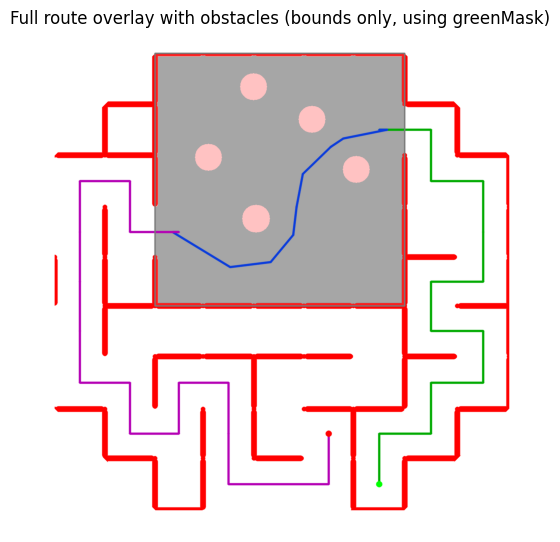

In [87]:
# ==== Visualize full path on the logical maze (with obstacle mask inside bounds, using greenMask) ====
import numpy as np, cv2, matplotlib.pyplot as plt

# expects: walls_white (BGR), x_lines, y_lines
#          comp_start=(r,c,heading), comp_goal=(r,c)
#          full_path_rc from astar_grid_turn(...)
#          pre_rc, post_rc, entry_cell, exit_cell from the split step
#          path (RRT* local pixel path) and (x1,y1,x2,y2) crop box if window used
#          greenMask (binary mask from circle_mask_fixed_radius)  <-- we will use this if available

# ---------------- helpers ----------------
def _cell_center_px(r, c, xs, ys):
    x = int(round(0.5*(xs[c] + xs[c+1])))
    y = int(round(0.5*(ys[r] + ys[r+1])))
    return (x, y)

def _rdp(points, eps_px):
    if len(points) <= 2 or eps_px <= 0:
        return [tuple(p) for p in points]
    P = np.asarray(points, float)
    a, b = P[0], P[-1]
    ab = b - a; ab2 = float((ab**2).sum())
    if ab2 == 0:
        idx = 0; dmax = 0.0
    else:
        t = np.clip(((P - a) @ ab) / ab2, 0, 1)
        proj = a + np.outer(t, ab)
        d = np.linalg.norm(P - proj, axis=1)
        idx = int(np.argmax(d)); dmax = float(d[idx])
    if dmax > eps_px:
        left  = _rdp(P[:idx+1], eps_px)
        right = _rdp(P[idx:],   eps_px)
        return left[:-1] + right
    else:
        return [tuple(a), tuple(b)]

def _to_int_pts(seq):
    out = []
    for p in seq:
        if p is None: continue
        try:
            x, y = float(p[0]), float(p[1])
            out.append((int(round(x)), int(round(y))))
        except Exception:
            pass
    return out

def _add_segment(segments, pts, color, thickness, label):
    pts_i = _to_int_pts(pts)
    if len(pts_i) >= 2:
        segments.append((pts_i, color, thickness, label))

def _bbox_pixels_from_bounds(xs, ys, bounds):
    xs = np.sort(np.asarray(xs).astype(int))
    ys = np.sort(np.asarray(ys).astype(int))
    c0, r0, c1, r1 = map(int, bounds)
    return int(xs[c0]), int(ys[r0]), int(xs[c1]), int(ys[r1])

def _mask_from_red(wbgr, dil=2):
    b,g,r = cv2.split(wbgr)
    m = ((r >= 200) & (g <= 30) & (b <= 30)).astype(np.uint8)*255
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, np.ones((3,3),np.uint8), 1)
    if dil>0: m = cv2.dilate(m, np.ones((dil,dil),np.uint8), 1)
    return m

# grid lines (pixels)
xs = np.sort(np.asarray(x_lines).astype(int))
ys = np.sort(np.asarray(y_lines).astype(int))

# base canvas (logical maze RGB)
canvas = cv2.cvtColor(walls_white, cv2.COLOR_BGR2RGB).copy()

# ------- build obstacle mask inside bounds (walls ∪ greenMask) -------
DILATE_WALLS = 2
DILATE_GREEN = 3

x1, y1, x2, y2 = _bbox_pixels_from_bounds(xs, ys, bounds)
crop_w = x2 - x1; crop_h = y2 - y1

# red walls → mask → crop
wall_mask_full = _mask_from_red(walls_white, dil=DILATE_WALLS)
crop_wall = wall_mask_full[y1:y2, x1:x2].copy()

# greenMask (if available) → normalize → crop/resize check
occ_crop = np.zeros((crop_h, crop_w), np.uint8)
if 'greenMask' in globals() and greenMask is not None:
    gm = greenMask
    if gm.ndim != 2:
        raise ValueError("greenMask must be single-channel (binary).")
    if gm.dtype != np.uint8: gm = gm.astype(np.uint8)
    if gm.max() == 1: gm = gm * 255

    if gm.shape[:2] == walls_white.shape[:2]:
        occ_crop = gm[y1:y2, x1:x2].copy()
    elif gm.shape[:2] == (crop_h, crop_w):
        occ_crop = gm.copy()
    else:
        raise ValueError(f"greenMask shape {gm.shape[:2]} must match full image {walls_white.shape[:2]} or crop {(crop_h,crop_w)}")

    if DILATE_GREEN > 0:
        occ_crop = cv2.dilate(occ_crop, np.ones((DILATE_GREEN, DILATE_GREEN), np.uint8), 1)

# union: walls ∪ green cylinders
occ_mask_window = cv2.bitwise_or(crop_wall, occ_crop)

# Blend only inside the crop
crop = canvas[y1:y2, x1:x2].copy()
tint = np.zeros_like(crop)
tint[occ_mask_window > 0] = (255, 80, 80)  # RGB red tint
blended = cv2.addWeighted(tint, 0.35, crop, 0.65, 0)  # 35% tint
canvas[y1:y2, x1:x2] = blended

# ------- build & draw path segments on top -------
C_PRE  = (0, 170, 0)     # green
C_RRT  = (10, 60, 220)   # blue-ish
C_POST = (180, 0, 180)   # magenta
TH = 4
segments = []

if 'entry_cell' not in globals() or entry_cell is None:
    # No window use → whole discrete path
    pre_pts = [_cell_center_px(r, c, xs, ys) for (r, c) in full_path_rc]
    _add_segment(segments, pre_pts, C_PRE, TH, "discrete")
else:
    # Pre (discrete) up to and including first inside cell
    pre_pts = [_cell_center_px(r, c, xs, ys) for (r, c) in pre_rc] if ('pre_rc' in globals()) else []
    if len(pre_pts) >= 2:
        _add_segment(segments, pre_pts, C_PRE, TH, "pre (grid)")

    # RRT* (lift local crop → global pixels)
    if 'path' in globals() and path is not None and len(path) >= 2:
        # If x1,y1 from elsewhere exist in globals, keep; else use ones computed above
        gl_x1 = globals().get('x1', x1); gl_y1 = globals().get('y1', y1)
        rrt_pts = [(int(gl_x1 + p[0]), int(gl_y1 + p[1])) for p in path]
        eps = max(2, int(0.02 * min(np.median(np.diff(xs)), np.median(np.diff(ys)))))
        rrt_pts = _rdp(rrt_pts, eps)
        _add_segment(segments, rrt_pts, C_RRT, TH, "rrt*")
        if pre_pts:
            _add_segment(segments, [pre_pts[-1], rrt_pts[0]], C_RRT, TH, "entry connector")

        if 'post_rc' in globals() and len(post_rc) >= 2:
            post_pts = [_cell_center_px(r, c, xs, ys) for (r, c) in post_rc]
            _add_segment(segments, [rrt_pts[-1], post_pts[0]], C_RRT, TH, "exit connector")
            _add_segment(segments, post_pts, C_POST, TH, "post (grid)")
        elif 'post_rc' in globals() and len(post_rc) == 1:
            post_pt = _cell_center_px(post_rc[0][0], post_rc[0][1], xs, ys)
            _add_segment(segments, [rrt_pts[-1], post_pt], C_RRT, TH, "exit connector")
    else:
        print("[warn] RRT* path not available; drawing only discrete segments if present.")
        if len(pre_pts) >= 2:
            _add_segment(segments, pre_pts, C_PRE, TH, "pre (grid)")
        if 'post_rc' in globals() and len(post_rc) >= 2:
            post_pts = [_cell_center_px(r, c, xs, ys) for (r, c) in post_rc]
            _add_segment(segments, post_pts, C_POST, TH, "post (grid)")

# draw
for pts, color, thick, _ in segments:
    for i in range(len(pts)-1):
        cv2.line(canvas, pts[i], pts[i+1], color, thick, cv2.LINE_AA)

# start & goal markers
sr, sc, _h0 = comp_start
gr, gc      = comp_goal
cv2.circle(canvas, _cell_center_px(sr, sc, xs, ys), 7, (0, 255, 0), -1, cv2.LINE_AA)  # start
cv2.circle(canvas, _cell_center_px(gr, gc, xs, ys), 7, (255, 0, 0), -1, cv2.LINE_AA)  # goal

# outline window
if 'bounds' in globals() and bounds is not None:
    c0, r0, c1, r1 = map(int, bounds)
    xL, xR = xs[c0], xs[c1]
    yT, yB = ys[r0], ys[r1]
    cv2.rectangle(canvas, (xL, yT), (xR, yB), (120, 120, 120), 2, cv2.LINE_AA)

plt.figure(figsize=(6.5, 6.5))
plt.imshow(canvas); plt.axis('off')
plt.title("Full route overlay with obstacles (bounds only, using greenMask)")
plt.show()
